# Commodity Diversification Analysis
*Andrea Botta & Gianluca Ladelfa - Starting Finance Club USI*

June 2026

## 1. Imports & Configuration

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import requests, zipfile, io, sys, warnings

from fredapi import Fred
from scipy import stats
from scipy.optimize import minimize
from arch import arch_model                                          # NEW
from statsmodels.tsa.regime_switching.markov_regression import (   # NEW
    MarkovRegression
)

warnings.filterwarnings("ignore")

FRED_API_KEY  = "4d661af47bd58d2509ca83a7a97345d6"
START_DATE    = "2004-01-01"
ROLLING_SHORT = 26
ROLLING_LONG  = 52

COLORS = {
    "sp500":  "#2c3e50", "dxy":    "#2980b9",
    "copper": "#c0392b", "silver": "#7f8c8d",
    "gold":   "#f39c12", "wheat":  "#d4ac0d",
    "natgas": "#1abc9c", "pos":    "#27ae60",
    "neg":    "#e74c3c", "neutral":"#95a5a6",
}

EVENTS = {
    "2008-09-15": "GFC",        "2011-08-05": "US Downgrade",
    "2015-08-11": "CNY Deval.", "2018-07-06": "Trade War",
    "2020-03-16": "COVID Shock","2022-02-24": "Ukraine War",
    "2022-09-01": "Fed Peak",   "2023-11-01": "Fed Pivot",
}

COMMODITIES = ["copper", "silver", "gold", "wheat", "natgas"]
ALL_ASSETS  = ["sp500", "dxy"] + COMMODITIES

## 2. Data Acquisition

### 2.1 Price Data

In [35]:
print("=" * 60)
print("1. DOWNLOAD PREZZI")
print("=" * 60)

tickers_map = {
    "sp500": "^GSPC", "dxy":    "DX-Y.NYB",
    "copper":"HG=F",  "silver": "SI=F",
    "gold":  "GC=F",  "wheat":  "ZW=F",
    "natgas":"NG=F",  "treasury":"^TNX",
}

raw = yf.download(
    list(tickers_map.values()),
    start=START_DATE, interval="1wk",
    progress=False
)["Close"]
raw = raw.rename(columns={v: k for k, v in tickers_map.items()})
raw.index = pd.to_datetime(raw.index.date)
df = raw.dropna()
print(f"   → {len(df)} settimane ({df.index[0]} → {df.index[-1]})")

1. DOWNLOAD PREZZI
   → 1174 settimane (2004-01-01 00:00:00 → 2026-06-25 00:00:00)


### 2.2 Macro Data (FRED)

In [36]:
print("\n2. FRED MACRO DATA")
fred = Fred(api_key=FRED_API_KEY)

fred_series_map = {
    "indpro":   "INDPRO",   "manemp":   "MANEMP",
    "vix":      "VIXCLS",   "fedfunds": "FEDFUNDS",
    "cpi":      "CPIAUCSL",
}
fred_frames = {}
for name, code in fred_series_map.items():
    s = fred.get_series(code, observation_start=START_DATE)
    s.index = pd.to_datetime(s.index.date)
    fred_frames[name] = s.resample("W").ffill()
    print(f"   OK  {code}")

macro_df = pd.DataFrame(fred_frames)


2. FRED MACRO DATA
   OK  INDPRO
   OK  MANEMP
   OK  VIXCLS
   OK  FEDFUNDS
   OK  CPIAUCSL


### 2.3 COT Report

In [37]:
print("\n3. COT REPORT (2011-2024)")

COT_KEYWORDS = {
    "copper":"COPPER", "silver":"SILVER", "gold":"GOLD",
    "wheat": "WHEAT",  "natgas":"NATURAL GAS",
}

cot_frames = []
for year in range(2010, 2025):
    url = (f"https://www.cftc.gov/files/dea/history/"
           f"fut_disagg_txt_{year}.zip")
    try:
        r = requests.get(url, timeout=90)
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            with z.open(z.namelist()[0]) as f:
                cot_frames.append(pd.read_csv(f, low_memory=False))
        print(f"   COT {year}: OK")
    except Exception as e:
        print(f"   COT {year}: {e}")

cot_all = pd.concat(cot_frames, ignore_index=True)
cot_all["date"] = pd.to_datetime(cot_all["Report_Date_as_YYYY-MM-DD"])

cot_series = {}
for asset, keyword in COT_KEYWORDS.items():
    mask = cot_all["Market_and_Exchange_Names"].str.contains(
        keyword, na=False, case=False
    )
    sub = cot_all[mask].copy().set_index("date")
    sub[f"cot_{asset}"] = (
        sub["M_Money_Positions_Long_All"] -
        sub["M_Money_Positions_Short_All"]
    )
    weekly = sub[[f"cot_{asset}"]].resample("W").last().ffill()
    cot_series[asset] = weekly
    print(f"   {asset}: {len(weekly)} settimane")

cot_df = pd.concat(cot_series.values(), axis=1)


3. COT REPORT (2011-2024)
   COT 2010: OK
   COT 2011: OK
   COT 2012: OK
   COT 2013: OK
   COT 2014: OK
   COT 2015: OK
   COT 2016: OK
   COT 2017: OK
   COT 2018: OK
   COT 2019: OK
   COT 2020: OK
   COT 2021: OK
   COT 2022: OK
   COT 2023: OK
   COT 2024: OK
   copper: 626 settimane
   silver: 626 settimane
   gold: 626 settimane
   wheat: 626 settimane
   natgas: 617 settimane


## 3. Data Merging

In [38]:
print("\n4. MERGE DATASET")

def _prep(frame):
    f = frame.reset_index()
    f.rename(columns={f.columns[0]: "date"}, inplace=True)
    f["date"] = pd.to_datetime(f["date"])
    if f["date"].dt.tz is not None:
        f["date"] = f["date"].dt.tz_localize(None)
    f["date"] = f["date"].astype("datetime64[ns]")
    f.sort_values("date", inplace=True)
    return f

df_r    = _prep(df)
macro_r = _prep(macro_df)
cot_r   = _prep(cot_df)

merged = pd.merge_asof(df_r, macro_r, on="date",
                       direction="backward").set_index("date").dropna()

merged_with_cot = pd.merge_asof(
    merged.reset_index(), cot_r,
    on="date", direction="backward"
).set_index("date")

d     = merged.copy()
d_cot = merged_with_cot.dropna(
    subset=[c for c in merged_with_cot.columns if c.startswith("cot_")]
).copy()

d = d.loc['2005-01-01':'2025-12-31']

d_cot = d_cot.loc['2010-01-01':'2025-12-31']

print(f"  Main Dataset (Core Analysis): {len(d)} weeks ({d.index[0].date()} -> {d.index[-1].date()})")
print(f"  ML Dataset (COT Focus):       {len(d_cot)} weeks ({d_cot.index[0].date()} -> {d_cot.index[-1].date()})")


4. MERGE DATASET
  Main Dataset (Core Analysis): 1057 weeks (2005-01-06 -> 2025-12-25)
  ML Dataset (COT Focus):       597 weeks (2013-01-17 -> 2024-11-07)


## 4. Feature Engineering

### 4.1 Analytical Variables

In [39]:
print("\n5. VARIABILI ANALITICHE")

for col in ["sp500", "dxy", "treasury"] + COMMODITIES:
    d[f"{col}_ret"]     = d[col].pct_change()
    d_cot[f"{col}_ret"] = d_cot[col].pct_change()

for col in ["sp500", "dxy"] + COMMODITIES:
    d[f"{col}_norm"] = (d[col] - d[col].min()) / (d[col].max() - d[col].min())

for c in COMMODITIES:
    d[f"{c}_ma4"]  = d[c].rolling(4).mean()
    d[f"{c}_ma12"] = d[c].rolling(12).mean()

d["dxy_ma52"]   = d["dxy"].rolling(52).mean()
d["dxy_regime"] = (d["dxy"] > d["dxy_ma52"]).astype(int)

d["riskoff"] = (d["vix"] > 25).astype(int)

d["cpi_yoy"] = d["cpi"].pct_change(52) * 100

for c in COMMODITIES:
    col = f"cot_{c}"
    if col in d_cot.columns:
        d_cot[f"cot_{c}_z"] = (
            (d_cot[col] - d_cot[col].rolling(52).mean()) /
            d_cot[col].rolling(52).std()
        )
for c in COMMODITIES:
    if f"cot_{c}_z" in d_cot.columns:
        d_cot[f"cot_{c}_signal"] = pd.cut(
            d_cot[f"cot_{c}_z"],
            bins=[-np.inf, -1, 0, 1, np.inf],
            labels=["Very Short","Neutral-Short","Neutral-Long","Very Long"]        
            )
        d_cot[f"{c}_ret_next"] = d_cot[f"{c}_ret"].shift(-1)

d = d.dropna()
print(f"   → {len(d)} righe dopo calcolo variabili")


5. VARIABILI ANALITICHE
   → 1005 righe dopo calcolo variabili


### 4.2 GARCH(1,1) — Conditional Volatility

In [40]:
print("\n5b. GARCH(1,1)")
print(f"   {'Asset':10s}  {'ω':>10}  {'α':>8}  {'β':>8}  "
      f"{'α+β':>8}  {'Vol̄ %':>8}")

garch_res    = {}
cond_vol     = {}   # pd.Series allineate a d.index
std_resid    = {}   # residui standardizzati (input per DCC)

for asset in ALL_ASSETS:
    y_pct = d[f"{asset}_ret"].dropna() * 100
    am  = arch_model(y_pct, vol="Garch", p=1, q=1,
                     dist="Normal", mean="Constant", rescale=False)
    res = am.fit(disp="off", show_warning=False)
    garch_res[asset] = res

    cond_vol[asset] = pd.Series(
        res.conditional_volatility.values / 100,
        index=y_pct.index
    ).reindex(d.index)

    std_resid[asset] = pd.Series(
        (res.resid / res.conditional_volatility).values,
        index=y_pct.index
    ).reindex(d.index)

    o   = res.params["omega"]
    a   = res.params["alpha[1]"]
    b   = res.params["beta[1]"]
    vm  = (res.conditional_volatility * np.sqrt(52)).mean()
    print(f"   {asset:10s}  {o:>10.5f}  {a:>8.4f}  {b:>8.4f}  "
          f"{a+b:>8.4f}  {vm:>8.2f}%")

    d[f"{asset}_garch_vol"] = (
        cond_vol[asset].reindex(d.index) * np.sqrt(52) * 100
    )

cond_vol_df = pd.DataFrame(cond_vol, index=d.index)


5b. GARCH(1,1)
   Asset                ω         α         β       α+β    Vol̄ %
   sp500          0.50503    0.1999    0.7163    0.9162     16.02%
   dxy            0.03842    0.0902    0.8759    0.9661      7.34%
   copper         0.42375    0.0777    0.8935    0.9711     26.62%
   silver         0.93007    0.0611    0.8952    0.9564     32.53%
   gold           0.35032    0.0827    0.8601    0.9429     17.59%
   wheat          1.78181    0.1065    0.8127    0.9192     32.98%
   natgas         4.21775    0.1956    0.7547    0.9503     56.65%


### 4.3 Markov Regime-Switching

In [41]:
print("\n5c. MARKOV REGIME-SWITCHING — S&P 500")

sp_pct = d["sp500_ret"].dropna() * 100
ms_sp  = MarkovRegression(sp_pct, k_regimes=2,
                          trend="c", switching_variance=True)
fit_sp = ms_sp.fit(disp=False)

mu0 = fit_sp.params["const[0]"]
mu1 = fit_sp.params["const[1]"]
bull_regime = int(mu1 > mu0)
bear_regime = 1 - bull_regime

print(f"   Bull (regime {bull_regime}): μ = {max(mu0,mu1):+.4f}%/week")
print(f"   Bear (regime {bear_regime}): μ = {min(mu0,mu1):+.4f}%/week")
print(f"   AIC: {fit_sp.aic:.1f}  |  Log-lik: {fit_sp.llf:.1f}")

smooth_probs = fit_sp.smoothed_marginal_probabilities
p_bull_raw   = smooth_probs.iloc[:, bull_regime]
p_bull_raw.index = d.index[:len(p_bull_raw)]

d["p_bull"]    = p_bull_raw.reindex(d.index, method="nearest").values
d["ms_regime"] = (d["p_bull"] > 0.5).astype(int)  # 1=bull, 0=bear

n_bull = d["ms_regime"].sum()
n_bear = len(d) - n_bull
print(f"   Bull: {n_bull} settimane ({n_bull/len(d)*100:.1f}%)")
print(f"   Bear: {n_bear} settimane ({n_bear/len(d)*100:.1f}%)")

print("\n   Gold — 3 regimi (safe-haven/neutro/risk-on)")
gold_pct = d["gold_ret"].dropna() * 100
try:
    ms_gold = MarkovRegression(gold_pct, k_regimes=3,
                               trend="c", switching_variance=True)
    fit_gold = ms_gold.fit(disp=False)
    mus_gold = sorted([
        (fit_gold.params[f"const[{i}]"], i) for i in range(3)
    ], reverse=True)
    labels_g = ["Risk-on", "Neutro", "Safe-haven"]
    for lab, (mu, idx) in zip(labels_g, mus_gold):
        print(f"   {lab:12s} (regime {idx}): μ = {mu:+.4f}%/week")
    print(f"   AIC gold 3-regime: {fit_gold.aic:.1f}")
except Exception as e:
    print(f"   Gold 3-regime FAIL: {e}")


5c. MARKOV REGIME-SWITCHING — S&P 500
   Bull (regime 0): μ = +0.4188%/week
   Bear (regime 1): μ = -0.3368%/week
   AIC: 4281.9  |  Log-lik: -2135.0
   Bull: 737 settimane (73.3%)
   Bear: 268 settimane (26.7%)

   Gold — 3 regimi (safe-haven/neutro/risk-on)
   Risk-on      (regime 2): μ = +0.2755%/week
   Neutro       (regime 1): μ = +0.2643%/week
   Safe-haven   (regime 0): μ = +0.0988%/week
   AIC gold 3-regime: 4577.1


### 4.4 DCC-GARCH — Dynamic Conditional Correlations

In [42]:
print("\n5d. DCC-GARCH")

def _dcc_negloglik(params, z1, z2):
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10
    rho_bar = np.corrcoef(z1, z2)[0, 1]
    Q_bar   = np.array([[1.0, rho_bar], [rho_bar, 1.0]])
    Q, ll   = Q_bar.copy(), 0.0
    for t in range(1, len(z1)):
        z = np.array([z1[t-1], z2[t-1]])
        Q = (1-a-b)*Q_bar + a*np.outer(z, z) + b*Q
        d_sq = np.sqrt(np.diag(Q))
        R    = Q / np.outer(d_sq, d_sq)
        R    = np.clip(R, -0.9999, 0.9999)
        try:
            sgn, logdet = np.linalg.slogdet(R)
            if sgn <= 0:
                return 1e10
            zt  = np.array([z1[t], z2[t]])
            ll += -0.5 * (logdet + zt @ np.linalg.inv(R) @ zt - zt @ zt)
        except Exception:
            return 1e10
    return -ll

def fit_dcc(s1: pd.Series, s2: pd.Series):
    """
    Stima DCC bivariate su residui standardizzati s1, s2 (pd.Series).
    Restituisce pd.Series di correlazioni dinamiche + parametri a, b.
    """
    common = s1.dropna().index.intersection(s2.dropna().index)
    z1, z2 = s1[common].values, s2[common].values
    rho_bar = np.corrcoef(z1, z2)[0, 1]

    opt = minimize(_dcc_negloglik, [0.05, 0.90], args=(z1, z2),
                   method="L-BFGS-B",
                   bounds=[(1e-6, 0.3), (1e-6, 0.9999)],
                   options={"maxiter": 500})
    a, b = opt.x

    Q_bar = np.array([[1.0, rho_bar], [rho_bar, 1.0]])
    Q     = Q_bar.copy()
    rho   = np.full(len(z1), rho_bar)
    for t in range(1, len(z1)):
        z   = np.array([z1[t-1], z2[t-1]])
        Q   = (1-a-b)*Q_bar + a*np.outer(z, z) + b*Q
        d_  = np.sqrt(np.diag(Q))
        R   = np.clip(Q / np.outer(d_, d_), -0.9999, 0.9999)
        rho[t] = R[0, 1]

    return pd.Series(rho, index=common), a, b

print(f"\n   {'Asset':10s}  {'α':>8}  {'β':>8}  {'α+β':>8}  "
      f"{'ρ̄ full':>8}  {'ρ̄ bull':>8}  {'ρ̄ bear':>8}  {'Δ':>8}")

dcc_sp500 = {}   # comm → pd.Series di correlazioni dinamiche vs SP500
dcc_dxy   = {}   # comm → pd.Series di correlazioni dinamiche vs DXY
dcc_params_sp500 = {}
dcc_params_dxy   = {}

z_sp500 = std_resid["sp500"]
z_dxy   = std_resid["dxy"]

for comm in COMMODITIES:
    z_c = std_resid[comm]

    rho_sp, a_sp, b_sp = fit_dcc(z_c, z_sp500)
    dcc_sp500[comm]        = rho_sp
    dcc_params_sp500[comm] = {"a": a_sp, "b": b_sp}

    ms_reg_aligned = d["ms_regime"].reindex(rho_sp.index, method="nearest")
    mu_bull = rho_sp[ms_reg_aligned == 1].mean()
    mu_bear = rho_sp[ms_reg_aligned == 0].mean()

    print(f"   {comm:10s}  {a_sp:>8.4f}  {b_sp:>8.4f}  "
          f"{a_sp+b_sp:>8.4f}  {rho_sp.mean():>8.4f}  "
          f"{mu_bull:>8.4f}  {mu_bear:>8.4f}  {mu_bear-mu_bull:>8.4f}")

    rho_dx, a_dx, b_dx = fit_dcc(z_c, z_dxy)
    dcc_dxy[comm]        = rho_dx
    dcc_params_dxy[comm] = {"a": a_dx, "b": b_dx}

dcc_sp500_df = pd.DataFrame(dcc_sp500)
dcc_dxy_df   = pd.DataFrame(dcc_dxy)


5d. DCC-GARCH

   Asset              α         β       α+β   ρ̄ full   ρ̄ bull   ρ̄ bear         Δ
   copper        0.0176    0.9772    0.9948    0.3704    0.3651    0.3850    0.0199
   silver        0.0000    0.0001    0.0001    0.2321    0.2321    0.2321    0.0000
   gold          0.0348    0.8232    0.8580    0.0657    0.0648    0.0682    0.0034
   wheat         0.0160    0.9577    0.9736    0.1094    0.1047    0.1223    0.0177
   natgas        0.0038    0.9845    0.9882    0.0935    0.0904    0.1019    0.0115


## 5. Statistical Analysis

In [43]:
print("\n" + "=" * 60)
print("6. ANALISI STATISTICA")
print("=" * 60)

print("\n── DCC media per regime Markov (SP500 bull/bear) ──")
print(f"{'Asset':10s} {'DCC full':>10} {'DCC bull':>10} "
      f"{'DCC bear':>10} {'Δ bear-bull':>12}")

for c in COMMODITIES:
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    full_m = rho_s.mean()
    bull_m = rho_s[d["ms_regime"] == 1].mean()
    bear_m = rho_s[d["ms_regime"] == 0].mean()
    print(f"{c:10s} {full_m:>+10.4f} {bull_m:>+10.4f} "
          f"{bear_m:>+10.4f} {bear_m-bull_m:>+12.4f}")

print("\n── DCC media vs SP500 per sotto-periodo ──")
sub_periods = {
    "2005-08": ("2005-01-01", "2008-08-31"),
    "2008-09": ("2008-09-01", "2009-06-30"),
    "2009-20": ("2009-07-01", "2020-02-28"),
    "2020":    ("2020-03-01", "2020-12-31"),
    "2021-22": ("2021-01-01", "2022-12-31"),
    "2023-25": ("2023-01-01", "2025-12-31"),
}

header = f"{'Period':10s}" + "".join(f"{c:>10s}" for c in COMMODITIES)
print(header)
print("-" * (10 + 10*len(COMMODITIES)))
sub_dcc_sp500 = {}
for label, (start, end) in sub_periods.items():
    row  = {}
    line = f"{label:10s}"
    for c in COMMODITIES:
        sub  = dcc_sp500[c].loc[start:end]
        r    = sub.mean() if len(sub) > 0 else np.nan
        row[c] = r
        line  += f"{r:>+10.3f}"
    sub_dcc_sp500[label] = row
    print(line)

print("\n── DCC vs SP500: Markov bull vs bear ──")
print(f"{'Asset':10s} {'DCC bull':>10} {'DCC bear':>10} {'Δ':>8}")
for c in COMMODITIES:
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    c_bull = rho_s[d["ms_regime"] == 1].mean()
    c_bear = rho_s[d["ms_regime"] == 0].mean()
    print(f"{c:10s} {c_bull:>+10.4f} {c_bear:>+10.4f} "
          f"{c_bear-c_bull:>+8.4f}")

print("\n── COT Signal: ritorno commodity settimana successiva ──")
for c in COMMODITIES:
    if f"cot_{c}_z" not in d_cot.columns:
        continue
    tbl = d_cot.groupby(
        f"cot_{c}_signal", observed=True
    )[f"{c}_ret_next"].agg(["mean","count"])
    tbl["mean_pct"] = tbl["mean"] * 100
    print(f"\n  {c.upper()}:")
    print(tbl[["mean_pct","count"]].to_string())

print("\n── Statistiche annualizzate ──")
print(f"{'Asset':10s} {'Ret%':>8} {'Vol%':>8} {'Sharpe':>8} "
      f"{'MaxDD%':>8} {'Beta':>8}")
print("-" * 55)

port_stats = {}
rf_weekly  = d["fedfunds"] / 100 / 52

for col in ["sp500"] + COMMODITIES:
    ret     = d[f"{col}_ret"].dropna()
    ann_ret = (1 + ret.mean())**52 - 1
    ann_vol = ret.std() * np.sqrt(52)
    excess  = ret - rf_weekly.reindex(ret.index).ffill()
    sharpe  = (excess.mean() / ret.std()) * np.sqrt(52)
    price   = (1 + ret).cumprod()
    maxdd   = (price / price.cummax() - 1).min()
    beta    = (stats.linregress(
        d["sp500_ret"].dropna(),
        d[f"{col}_ret"].dropna()
    ).slope if col != "sp500" else 1.0)

    port_stats[col] = {
        "ann_ret": ann_ret, "ann_vol": ann_vol,
        "sharpe":  sharpe,  "maxdd":   maxdd,  "beta": beta
    }
    print(f"{col:10s} {ann_ret*100:>+8.1f} {ann_vol*100:>8.1f} "
          f"{sharpe:>8.2f} {maxdd*100:>8.1f} {beta:>8.2f}")

sys.stdout.flush()


6. ANALISI STATISTICA

── DCC media per regime Markov (SP500 bull/bear) ──
Asset        DCC full   DCC bull   DCC bear  Δ bear-bull
copper        +0.3704    +0.3651    +0.3850      +0.0199
silver        +0.2321    +0.2321    +0.2321      +0.0000
gold          +0.0657    +0.0648    +0.0682      +0.0034
wheat         +0.1094    +0.1047    +0.1223      +0.0177
natgas        +0.0935    +0.0904    +0.1019      +0.0115

── DCC media vs SP500 per sotto-periodo ──
Period        copper    silver      gold     wheat    natgas
------------------------------------------------------------
2005-08       +0.247    +0.232    +0.069    +0.075    +0.091
2008-09       +0.375    +0.232    +0.075    +0.178    +0.091
2009-20       +0.413    +0.232    +0.059    +0.123    +0.083
2020          +0.433    +0.232    +0.104    +0.165    +0.129
2021-22       +0.369    +0.232    +0.076    +0.071    +0.117
2023-25       +0.310    +0.232    +0.066    +0.082    +0.108

── DCC vs SP500: Markov bull vs bear ──
Asset    

## 6. Visualization

In [44]:
def _shade_bear(ax, index, bear_series, color="#e74c3c", alpha=0.18):
    for t in range(len(index) - 1):
        if bear_series.iloc[t]:
            ax.axvspan(index[t], index[t+1],
                       alpha=alpha, color=color, linewidth=0)

comm_labels = {
    "copper":"Copper","silver":"Silver","gold":"Gold",
    "wheat":"Wheat", "natgas":"Nat. Gas"
}

print("\n7. GENERAZIONE FIGURE")
bear_mask_d = (d["ms_regime"] == 0)   # Markov bear regime


7. GENERAZIONE FIGURE


### Figure 1 — Price Overview & Markov Regime

In [45]:
fig1, axes1 = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig1.suptitle(
    "Commodity Markets Overview 2005–2025\n"
    "Normalized Price Levels & Markov Regime",
    fontsize=14, fontweight="bold", y=0.99
)

ax = axes1[0]
ax.plot(d.index, d["sp500_norm"],
        color=COLORS["sp500"], linewidth=1.5, label="S&P 500")
_shade_bear(ax, d.index, bear_mask_d, color="#e74c3c")
for ds, lbl in EVENTS.items():
    try:
        dt = pd.Timestamp(ds)
        if d.index[0] <= dt <= d.index[-1]:
            ax.axvline(dt, color="gray", linewidth=0.7, linestyle=":")
            ax.text(dt, 0.95, lbl, fontsize=6.5, rotation=90,
                    va="top", ha="right", color="gray")
    except Exception:
        pass
ax.set_ylabel("Normalized (0–1)")
ax.set_title("S&P 500 — Bull (white) / Bear (red) Regime [Markov Switching]",
             fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes1[1]
for c, col in [("gold",COLORS["gold"]),("silver",COLORS["silver"]),
               ("copper",COLORS["copper"])]:
    ax.plot(d.index, d[f"{c}_norm"], color=col,
            linewidth=1.2, label=comm_labels[c], alpha=0.9)
ax.set_ylabel("Normalized (0–1)")
ax.set_title("Precious & Industrial Metals — Normalized", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes1[2]
for c, col in [("wheat",COLORS["wheat"]),("natgas",COLORS["natgas"])]:
    ax.plot(d.index, d[f"{c}_norm"], color=col,
            linewidth=1.2, label=comm_labels[c], alpha=0.9)
ax.plot(d.index, d["dxy_norm"], color=COLORS["dxy"],
        linewidth=1.2, label="DXY", alpha=0.8, linestyle="--")
ax.set_ylabel("Normalized (0–1)")
ax.set_title("Agricultural (Wheat), Energy (Nat. Gas) vs DXY — Normalized",
             fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.savefig("fig1_overview.png", dpi=150, bbox_inches="tight")
plt.close()
print("   → fig1_overview.png")

   → fig1_overview.png


### Figure GARCH — Conditional Volatility & Regime Probabilities

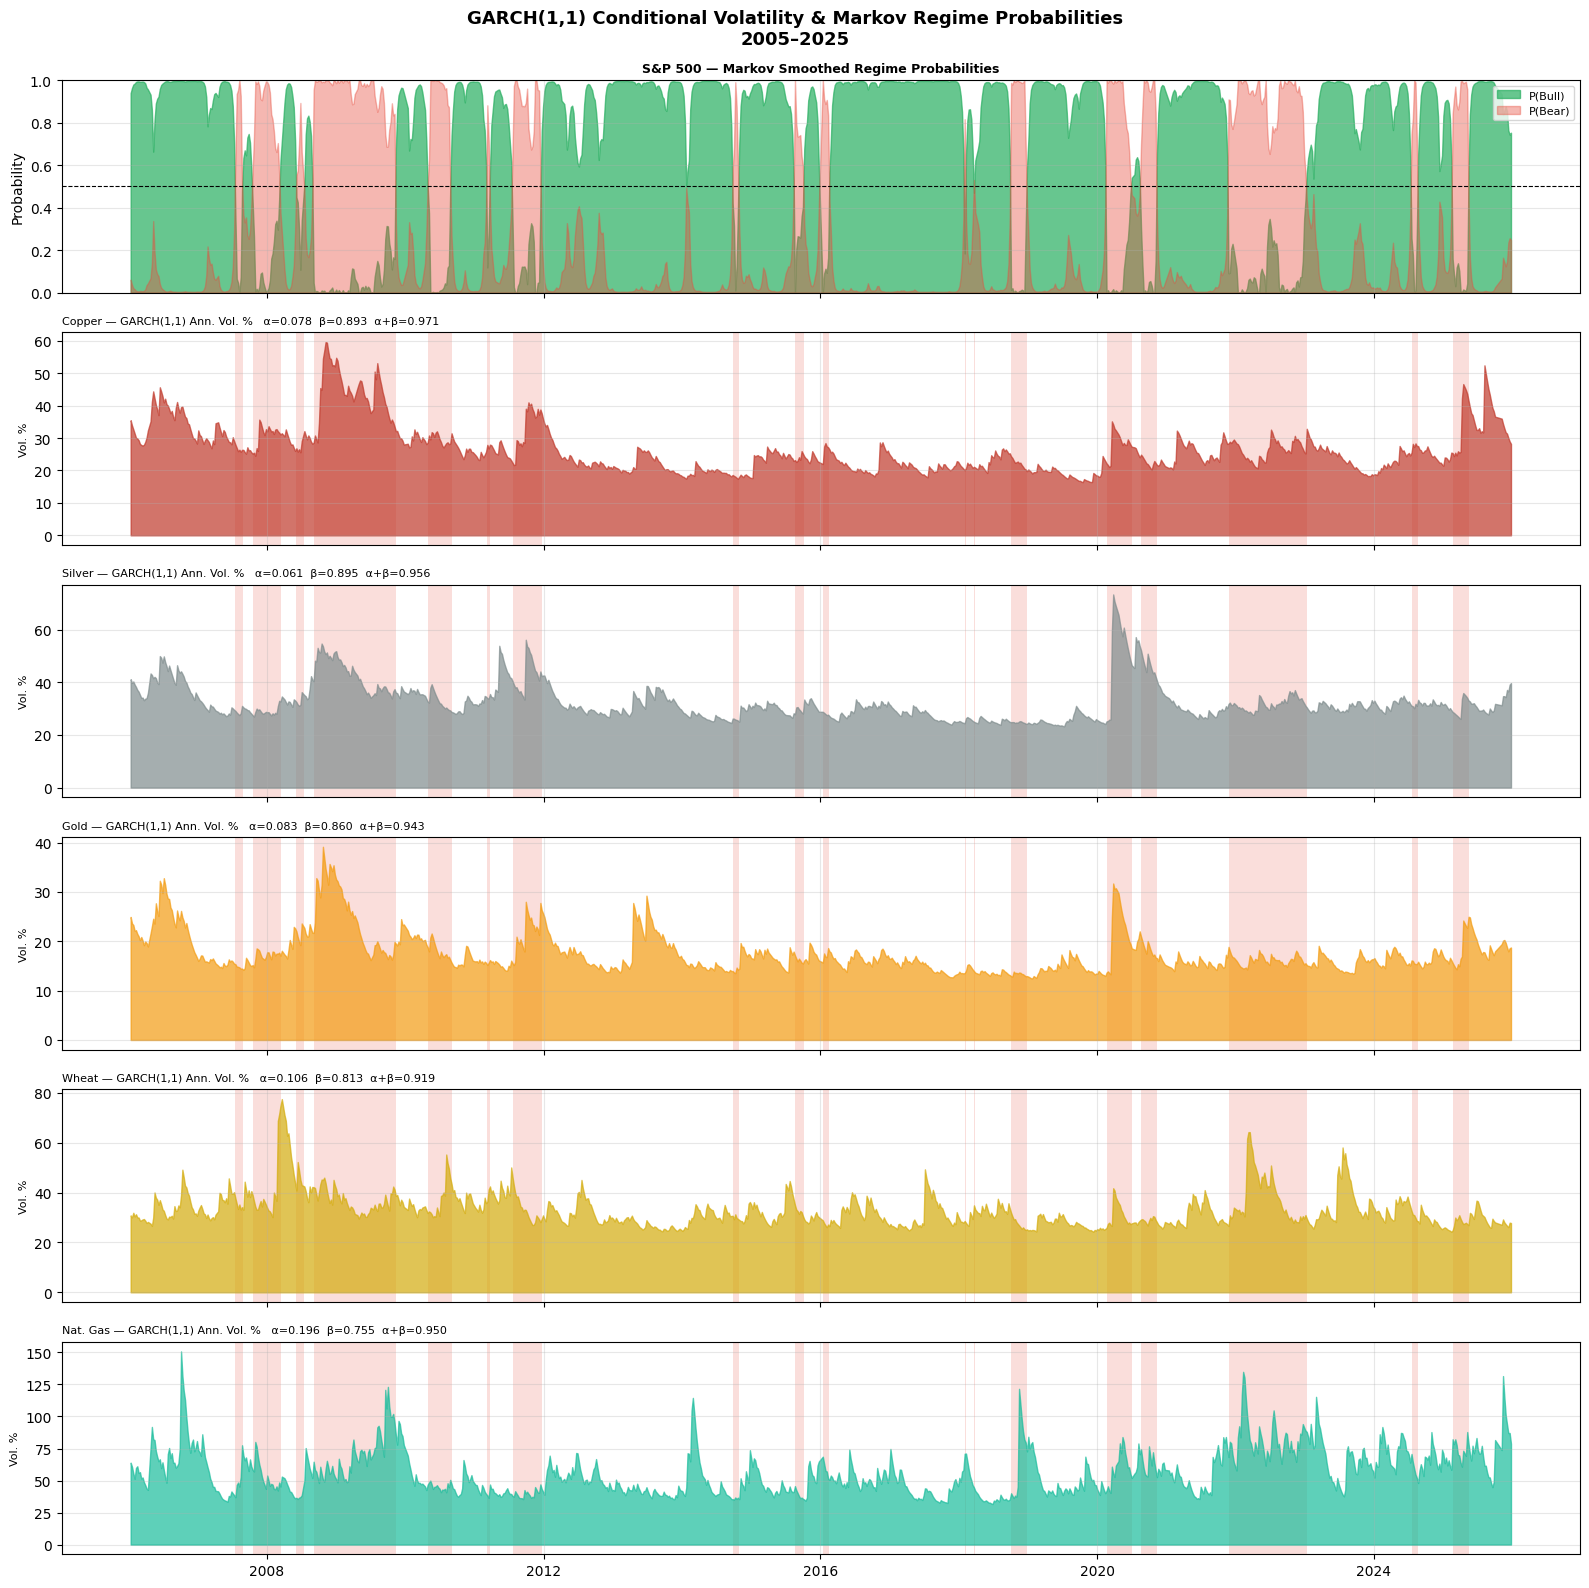

In [46]:
fig_gr, axes_gr = plt.subplots(
    len(COMMODITIES) + 1, 1, figsize=(16, 16), sharex=True
)
fig_gr.suptitle(
    "GARCH(1,1) Conditional Volatility & Markov Regime Probabilities\n"
    "2005–2025",
    fontsize=13, fontweight="bold", y=0.99
)

ax = axes_gr[0]
ax.fill_between(d.index, d["p_bull"].values, 0,
                color=COLORS["pos"], alpha=0.7, label="P(Bull)")
ax.fill_between(d.index, 1 - d["p_bull"].values, 0,
                color=COLORS["neg"], alpha=0.4, label="P(Bear)")
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Probability") # Tradotto
ax.set_ylim(0, 1)
ax.set_title("S&P 500 — Markov Smoothed Regime Probabilities",
             fontweight="bold", fontsize=9)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

for i, comm in enumerate(COMMODITIES):
    ax = axes_gr[i + 1]
    col_gvol = f"{comm}_garch_vol"
    _shade_bear(ax, d.index, bear_mask_d)
    ax.fill_between(d.index, d[col_gvol].values, 0,
                    color=COLORS[comm], alpha=0.7)
    p_garch = garch_res[comm].params
    ax.set_title(
        f"{comm_labels[comm]} — GARCH(1,1) Ann. Vol. %   "
        f"α={p_garch['alpha[1]']:.3f}  "
        f"β={p_garch['beta[1]']:.3f}  "
        f"α+β={p_garch['alpha[1]']+p_garch['beta[1]']:.3f}",
        fontsize=8, loc="left"
    )
    ax.set_ylabel("Vol. %", fontsize=8)
    ax.grid(True, alpha=0.3)

axes_gr[-1].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%Y")
)
plt.tight_layout()
plt.savefig("fig_garch_regime.png", dpi=150, bbox_inches="tight")
plt.show("fig_garch_regime.png")
plt.close()

### Figure 2 — DCC vs S&P 500

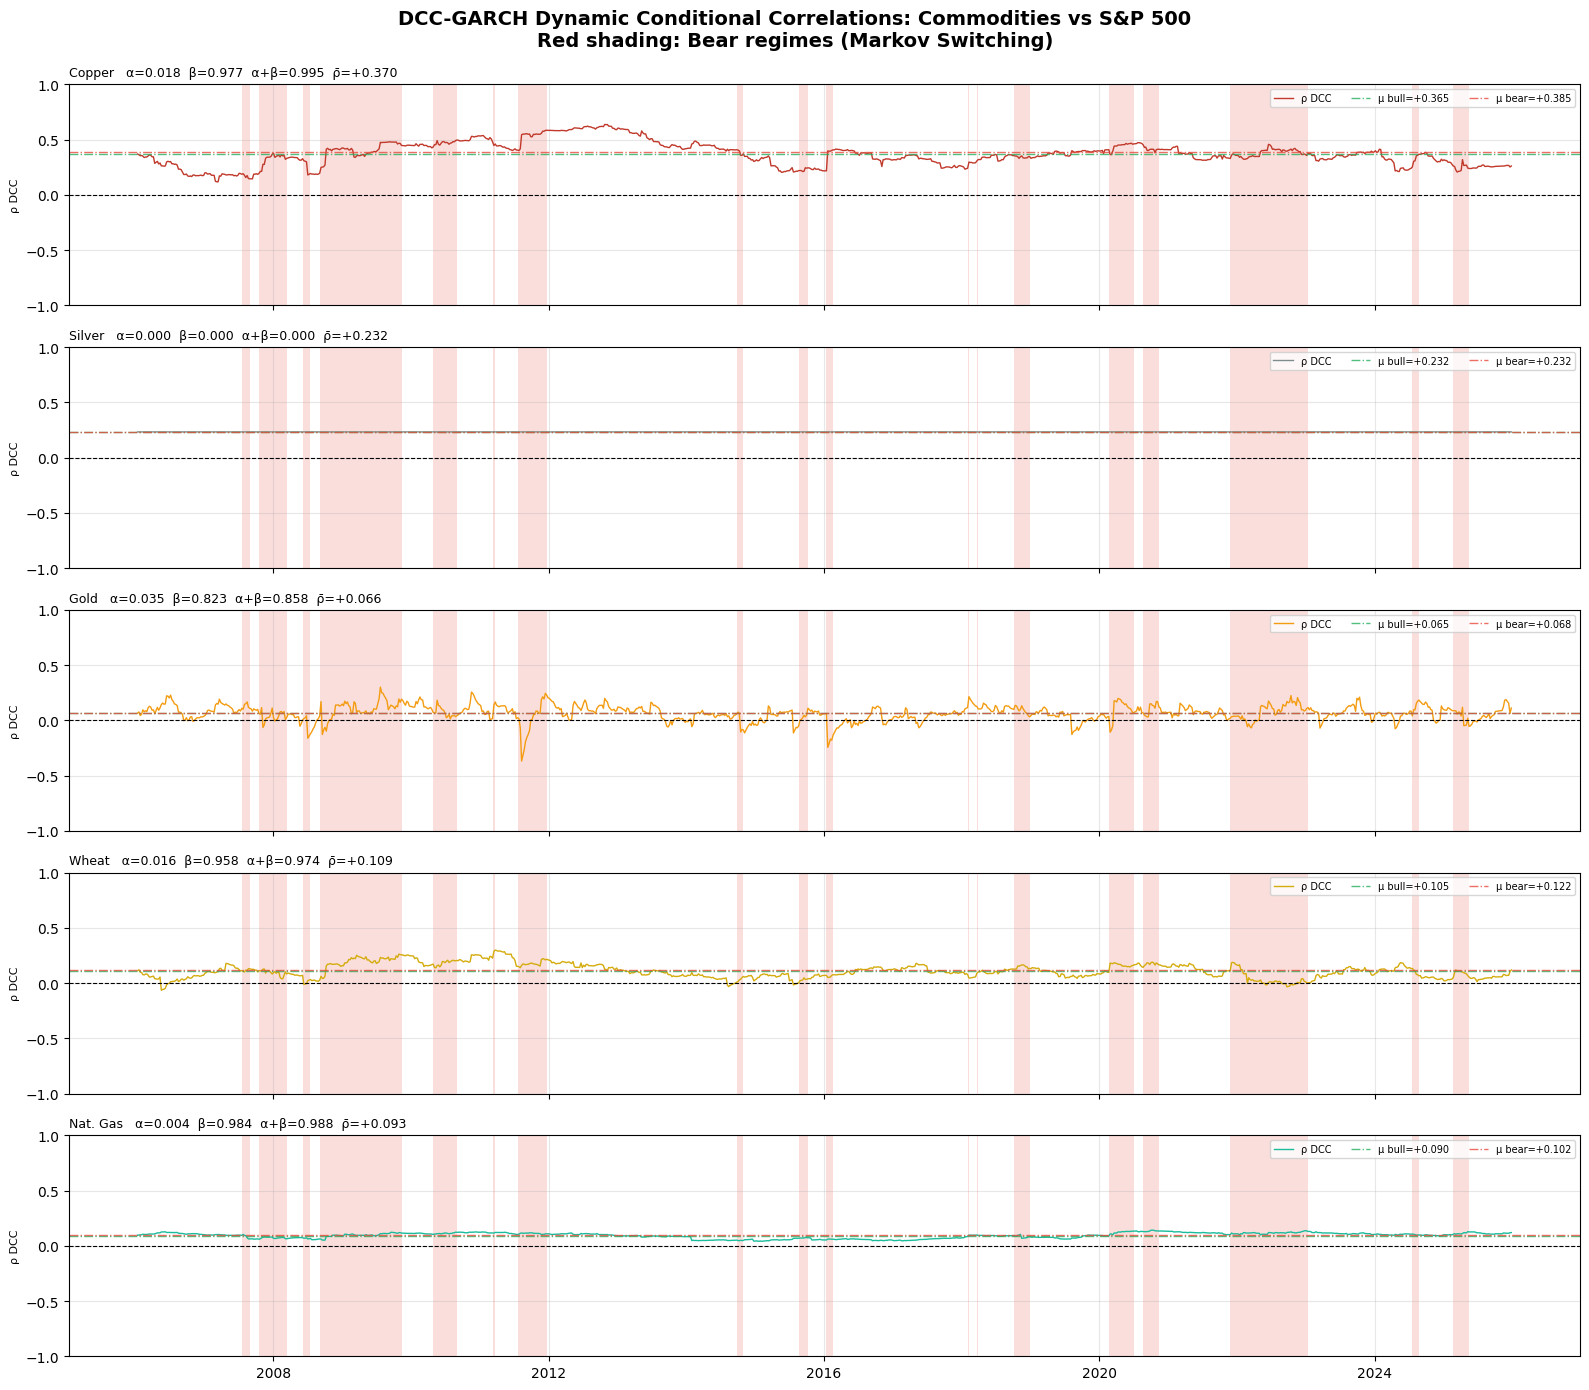

In [47]:
fig2, axes2 = plt.subplots(len(COMMODITIES), 1,
                            figsize=(16, 14), sharex=True)
fig2.suptitle(
    "DCC-GARCH Dynamic Conditional Correlations: Commodities vs S&P 500\n"
    "Red shading: Bear regimes (Markov Switching)", # Tradotto
    fontsize=14, fontweight="bold", y=0.99
)

for i, c in enumerate(COMMODITIES):
    ax    = axes2[i]
    rho_s = dcc_sp500[c]

    bear_dcc = bear_mask_d.reindex(rho_s.index, method="nearest")
    _shade_bear(ax, rho_s.index, bear_dcc)

    ax.plot(rho_s.index, rho_s.values,
            color=COLORS[c], linewidth=1.0, label="ρ DCC")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ms_aligned = d["ms_regime"].reindex(rho_s.index, method="nearest")
    mu_bull = rho_s[ms_aligned == 1].mean()
    mu_bear = rho_s[ms_aligned == 0].mean()
    ax.axhline(mu_bull, color=COLORS["pos"], linewidth=1.0,
               linestyle="-.", alpha=0.8,
               label=f"μ bull={mu_bull:+.3f}")
    ax.axhline(mu_bear, color=COLORS["neg"], linewidth=1.0,
               linestyle="-.", alpha=0.8,
               label=f"μ bear={mu_bear:+.3f}")

    p = dcc_params_sp500[c]
    ax.set_title(
        f"{comm_labels[c]}   "
        f"α={p['a']:.3f}  β={p['b']:.3f}  α+β={p['a']+p['b']:.3f}  "
        f"ρ̄={rho_s.mean():+.3f}",
        fontsize=9, loc="left"
    )
    ax.set_ylabel("ρ DCC", fontsize=8)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7, loc="upper right", ncol=3)
    ax.grid(True, alpha=0.3)

axes2[-1].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%Y")
)
plt.tight_layout()
plt.savefig("fig2_dcc_sp500.png", dpi=150, bbox_inches="tight")
plt.show("fig2_dcc_sp500.png")
plt.close()

### Figure 3 — DCC vs DXY

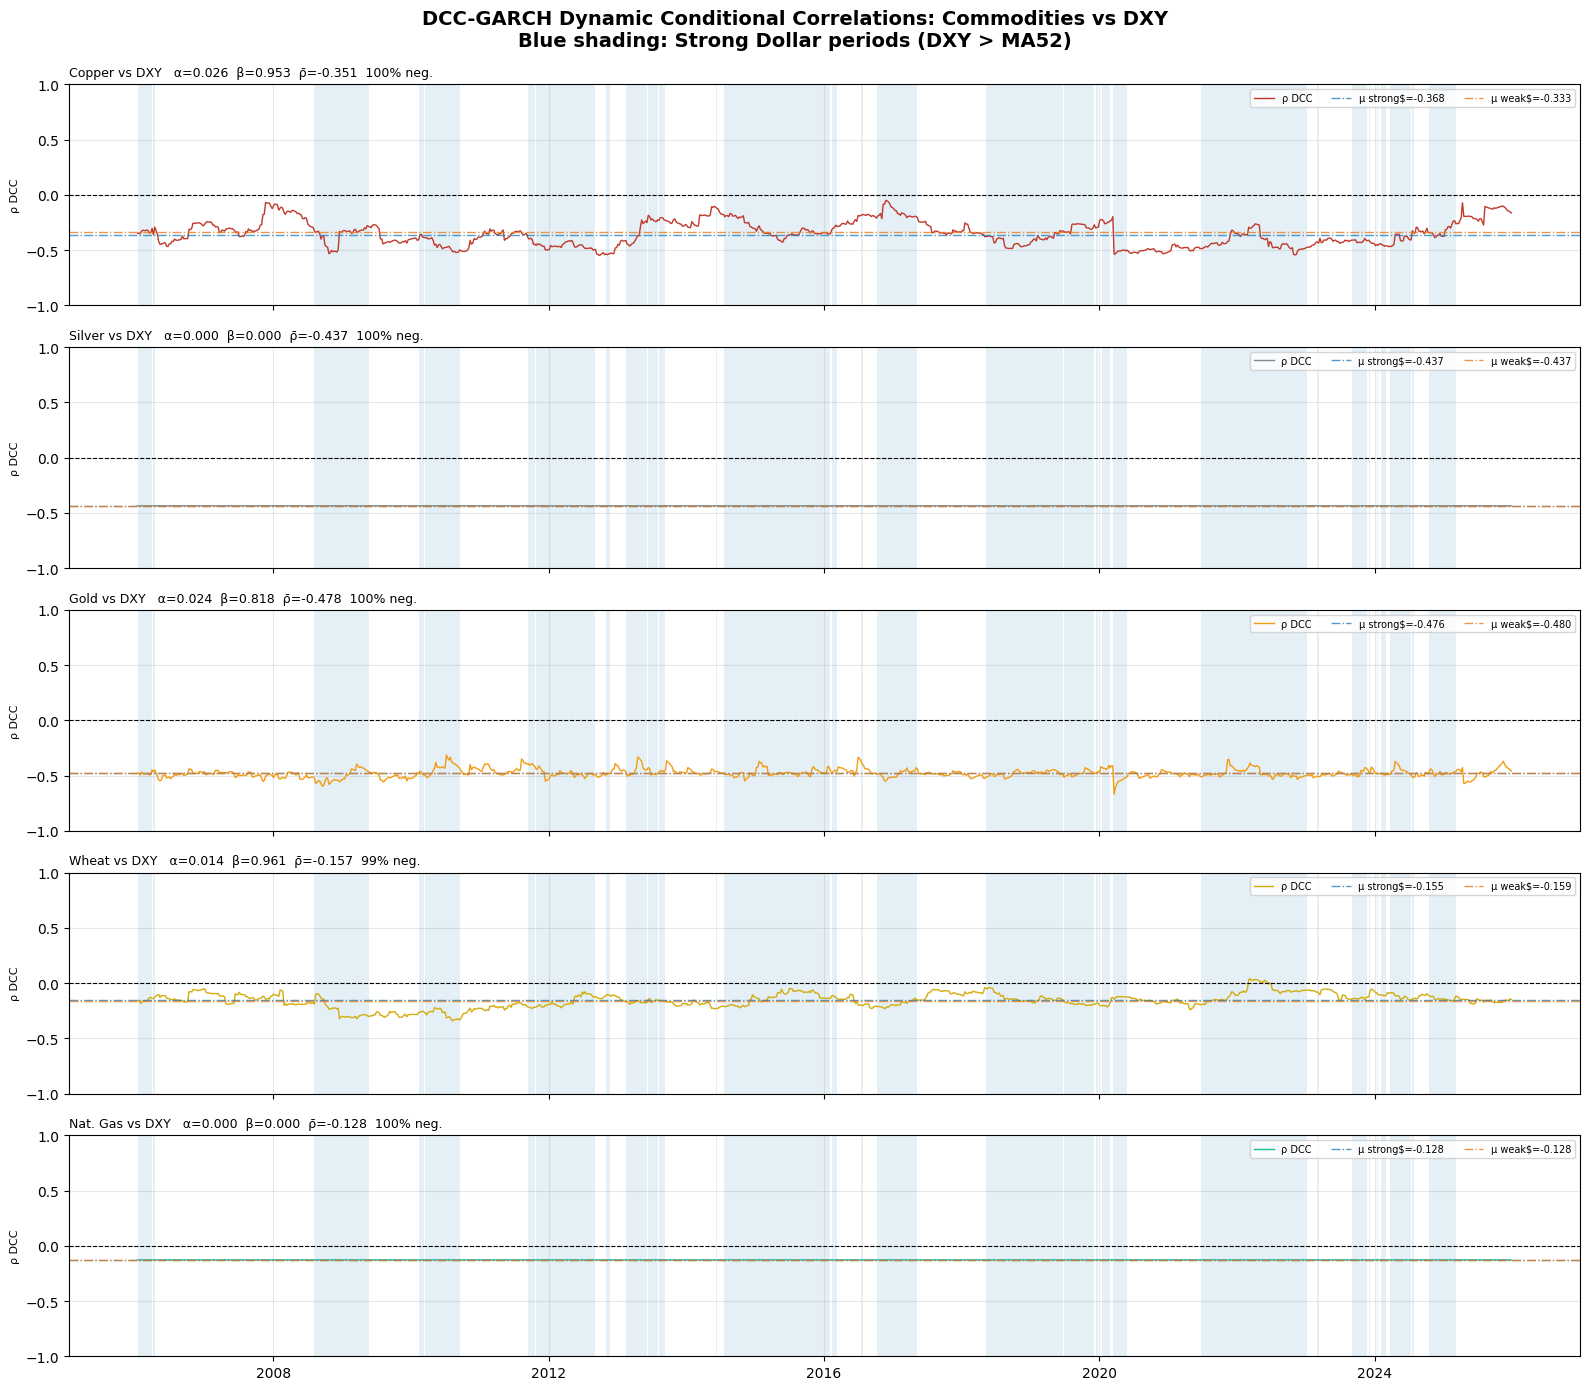

In [48]:
strong_dxy_mask = (d["dxy_regime"] == 1)

fig3, axes3 = plt.subplots(len(COMMODITIES), 1,
                            figsize=(16, 14), sharex=True)
fig3.suptitle(
    "DCC-GARCH Dynamic Conditional Correlations: Commodities vs DXY\n"
    "Blue shading: Strong Dollar periods (DXY > MA52)", # Tradotto
    fontsize=14, fontweight="bold", y=0.99
)

for i, c in enumerate(COMMODITIES):
    ax    = axes3[i]
    rho_s = dcc_dxy[c]

    strong_aligned = strong_dxy_mask.reindex(rho_s.index, method="nearest")
    _shade_bear(ax, rho_s.index, strong_aligned,
                color=COLORS["dxy"], alpha=0.12)

    ax.plot(rho_s.index, rho_s.values,
            color=COLORS[c], linewidth=1.0, label="ρ DCC")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    mu_strong = rho_s[strong_aligned].mean()
    mu_weak   = rho_s[~strong_aligned].mean()
    ax.axhline(mu_strong, color=COLORS["dxy"], linewidth=1.0,
               linestyle="-.", alpha=0.8,
               label=f"μ strong$={mu_strong:+.3f}")
    ax.axhline(mu_weak, color="#e67e22", linewidth=1.0,
               linestyle="-.", alpha=0.8,
               label=f"μ weak$={mu_weak:+.3f}")

    pct_neg = (rho_s < 0).mean() * 100
    p = dcc_params_dxy[c]
    ax.set_title(
        f"{comm_labels[c]} vs DXY   "
        f"α={p['a']:.3f}  β={p['b']:.3f}  "
        f"ρ̄={rho_s.mean():+.3f}  "
        f"{pct_neg:.0f}% neg.",
        fontsize=9, loc="left"
    )
    ax.set_ylabel("ρ DCC", fontsize=8)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7, loc="upper right", ncol=3)
    ax.grid(True, alpha=0.3)

axes3[-1].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%Y")
)
plt.tight_layout()
plt.savefig("fig3_dcc_dxy.png", dpi=150, bbox_inches="tight")
plt.show("fig3_dcc_dxy.png")
plt.close()

### Figure 4 — DCC Sub-Period Heatmap

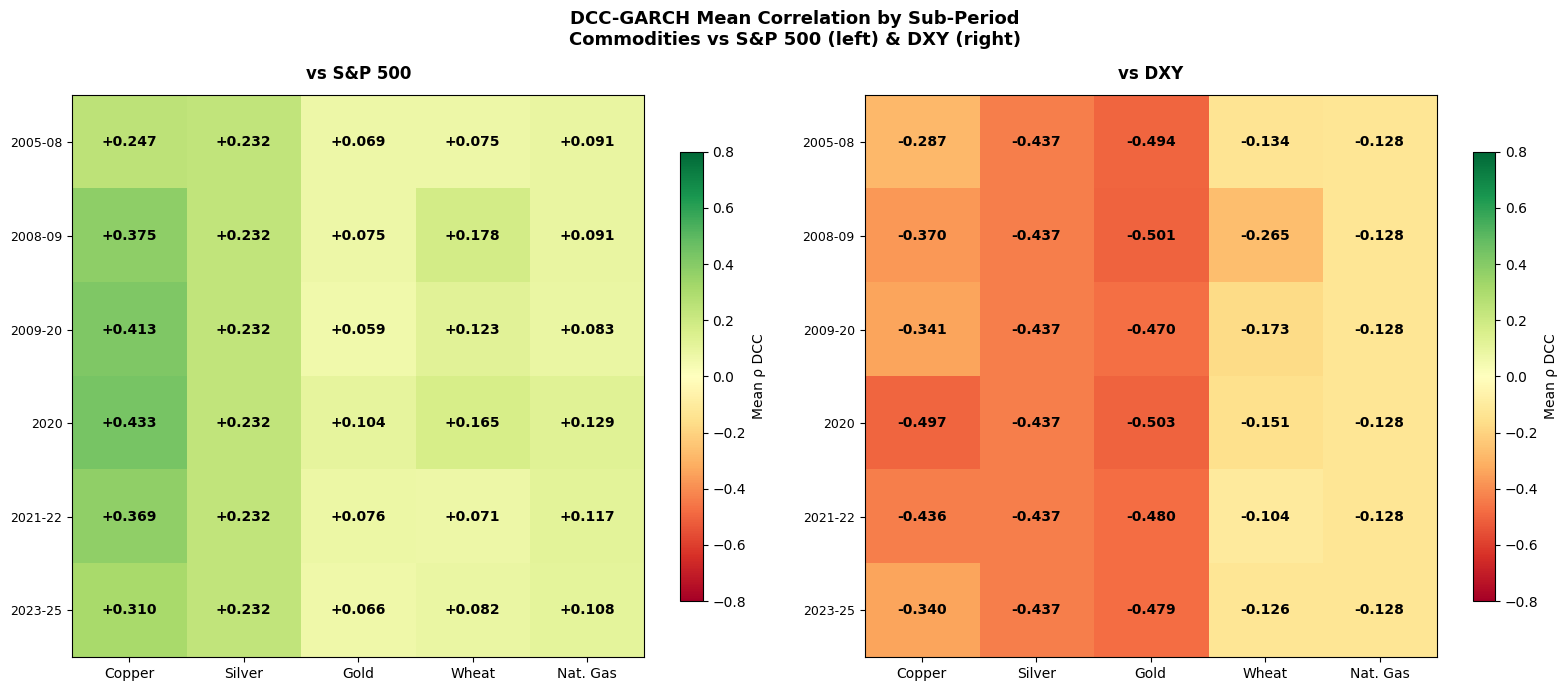

In [49]:
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(16, 7))
fig4.suptitle(
    "DCC-GARCH Mean Correlation by Sub-Period\n"
    "Commodities vs S&P 500 (left) & DXY (right)",
    fontsize=13, fontweight="bold"
)

def plot_dcc_heatmap(ax, dcc_dict, periods, title):
    comm_list = list(dcc_dict.keys())
    per_list  = list(periods.keys())
    mat = np.full((len(per_list), len(comm_list)), np.nan)
    for i, (label, (start, end)) in enumerate(periods.items()):
        for j, c in enumerate(comm_list):
            sub = dcc_dict[c].loc[start:end]
            if len(sub) > 0:
                mat[i, j] = sub.mean()

    norm = mcolors.TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)
    im   = ax.imshow(mat, cmap="RdYlGn", norm=norm, aspect="auto")
    ax.set_xticks(range(len(comm_list)))
    ax.set_xticklabels([comm_labels[c] for c in comm_list], fontsize=10)
    ax.set_yticks(range(len(per_list)))
    ax.set_yticklabels(per_list, fontsize=9)
    for i in range(len(per_list)):
        for j in range(len(comm_list)):
            if not np.isnan(mat[i, j]):
                tc = "white" if abs(mat[i,j]) > 0.55 else "black"
                ax.text(j, i, f"{mat[i,j]:+.3f}",
                        ha="center", va="center",
                        fontsize=10, fontweight="bold", color=tc)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Mean ρ DCC") # Tradotto
    ax.set_title(title, fontweight="bold", pad=12)

plot_dcc_heatmap(ax4a, dcc_sp500, sub_periods, "vs S&P 500")
plot_dcc_heatmap(ax4b, dcc_dxy,   sub_periods, "vs DXY")

plt.tight_layout()
plt.savefig("fig4_dcc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show("fig4_dcc_heatmap.png")
plt.close()

### Figure 5 — COT Signal Analysis

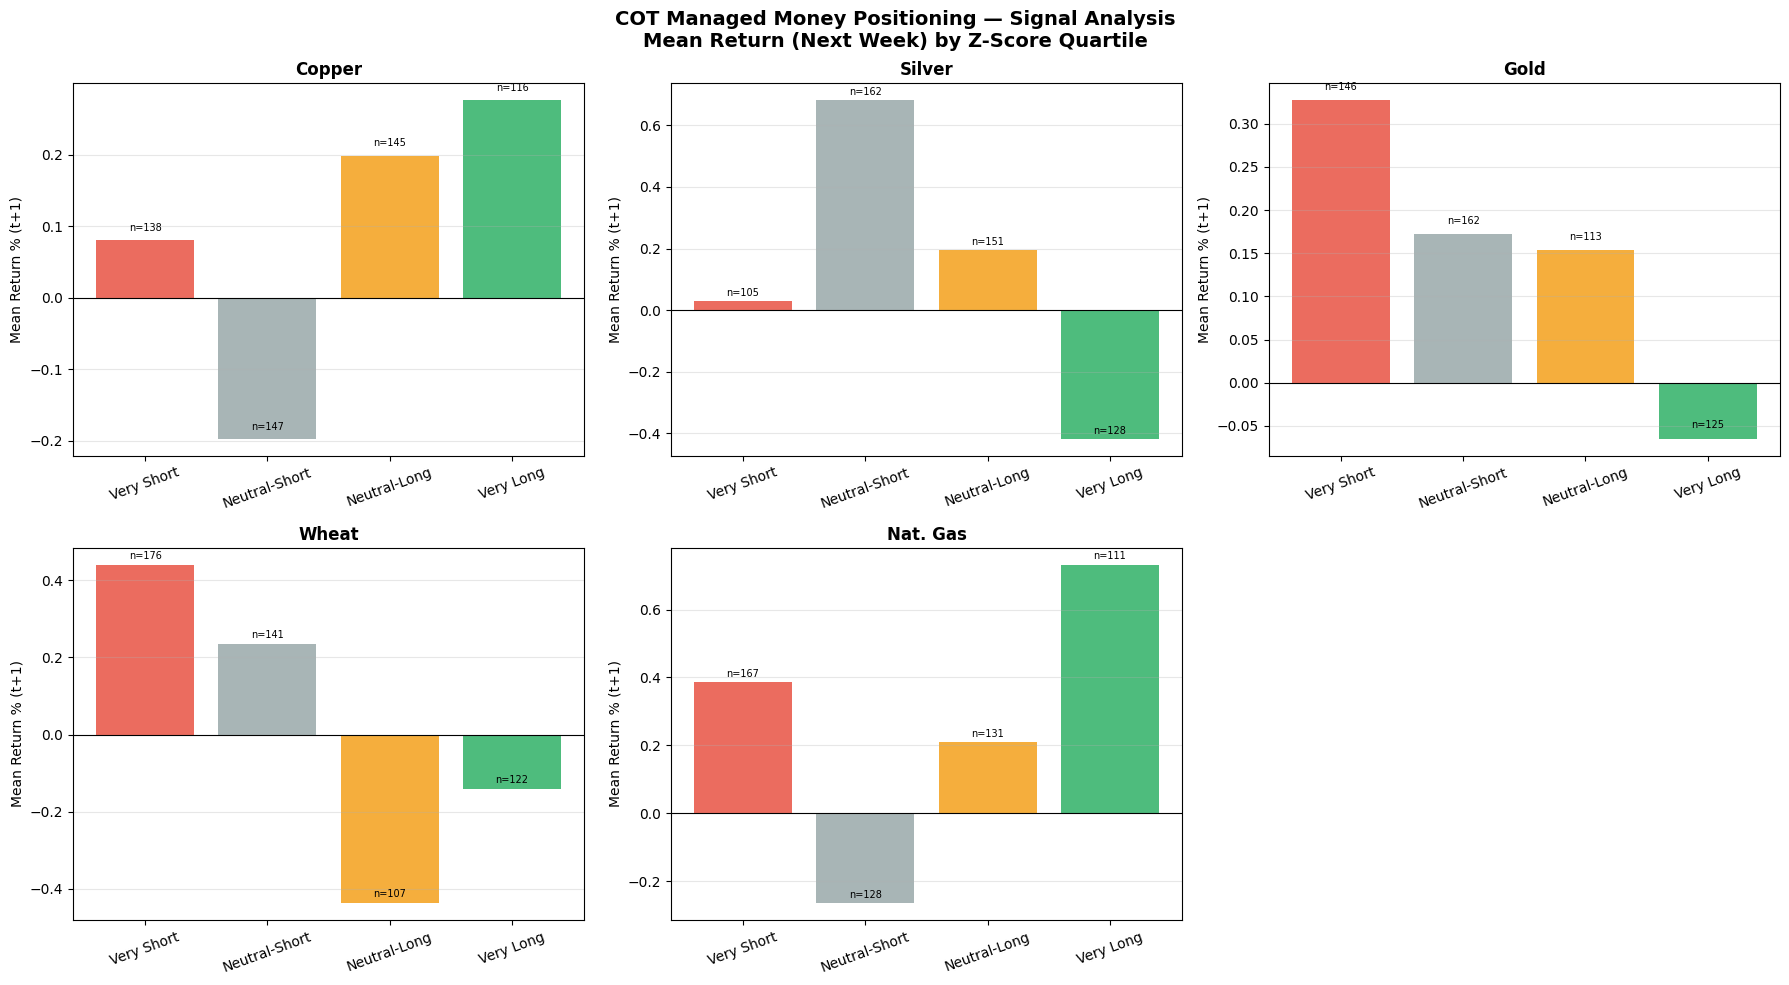

In [50]:
fig5, axes5 = plt.subplots(2, 3, figsize=(18, 10))
fig5.suptitle(
    "COT Managed Money Positioning — Signal Analysis\n"
    "Mean Return (Next Week) by Z-Score Quartile",
    fontsize=14, fontweight="bold"
)
axes5 = axes5.flatten()
bar_colors = [COLORS["neg"], COLORS["neutral"], "#f39c12", COLORS["pos"]]

for i, c in enumerate(COMMODITIES):
    ax = axes5[i]
    if f"cot_{c}_signal" not in d_cot.columns:
        ax.set_visible(False)
        continue

    labels = ["Very Short","Neutral-Short","Neutral-Long","Very Long"]
    means  = [d_cot[d_cot[f"cot_{c}_signal"]==lb][f"{c}_ret_next"].mean()*100
              for lb in labels]
    counts = [len(d_cot[d_cot[f"cot_{c}_signal"]==lb]) for lb in labels]

    bars = ax.bar(labels, means, color=bar_colors, alpha=0.82)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(comm_labels[c], fontweight="bold")
    ax.set_ylabel("Mean Return % (t+1)") # Tradotto
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01, f"n={n}",
                ha="center", va="bottom", fontsize=7)

axes5[5].set_visible(False)
plt.tight_layout()
plt.savefig("fig5_cot_signals.png", dpi=150, bbox_inches="tight")
plt.show("fig5_cot_signals.png")
plt.close()

### Figure 6 — Portfolio Metrics

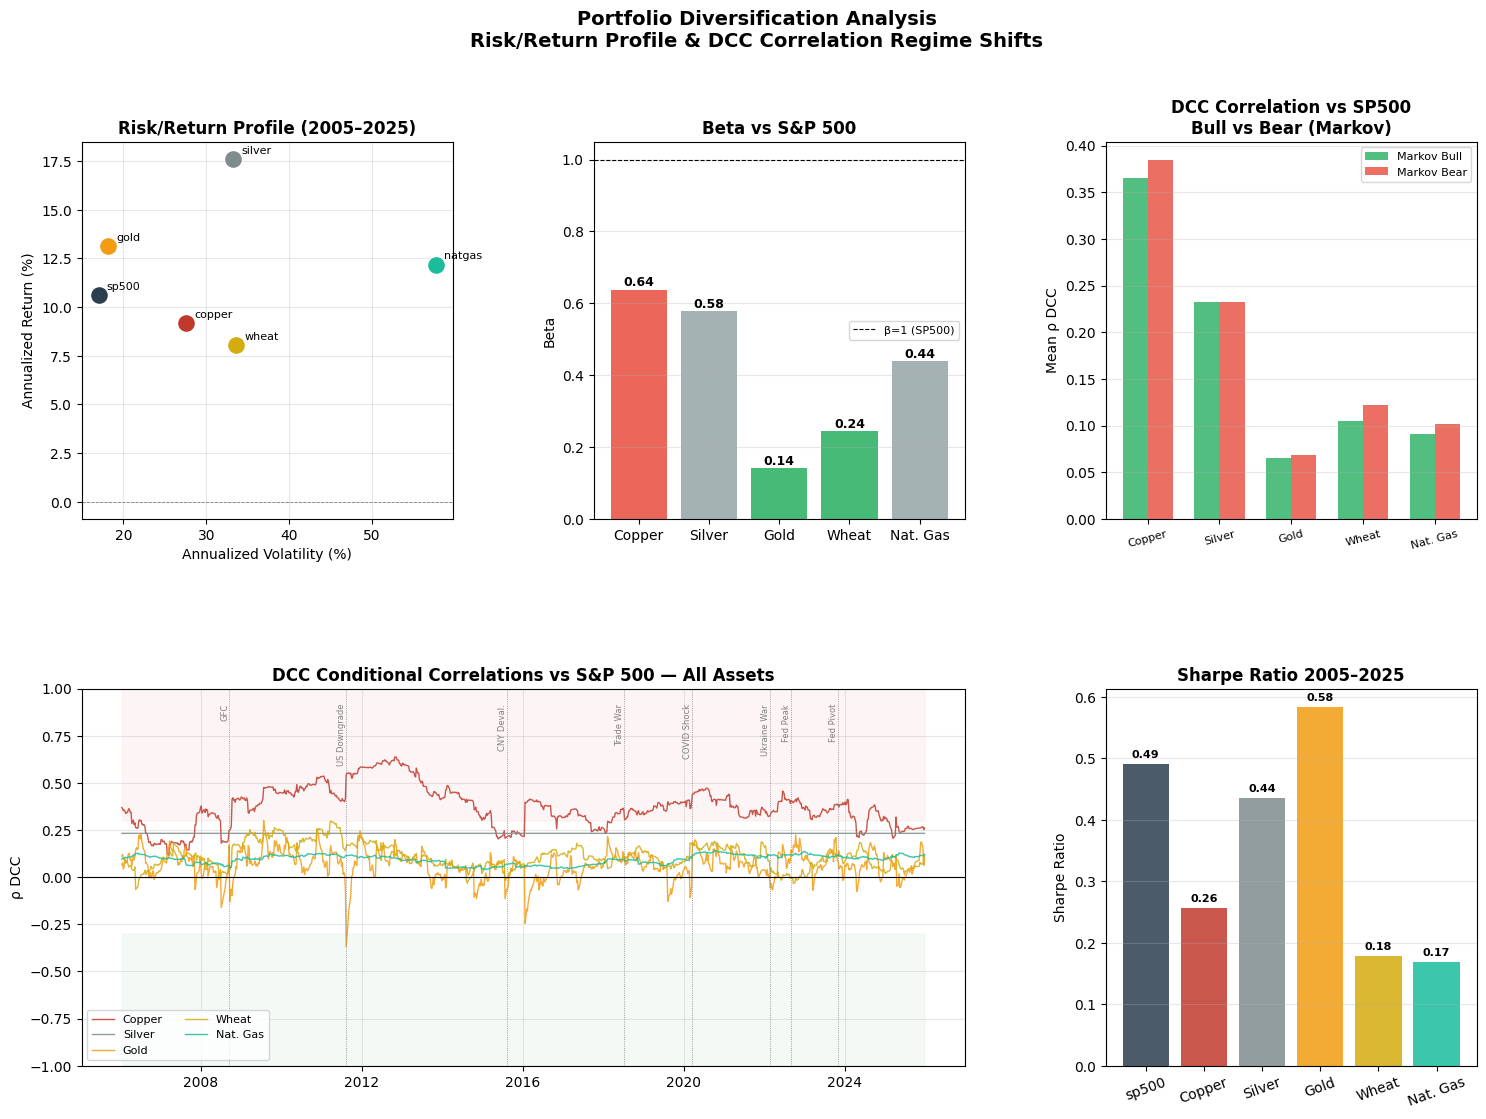

In [51]:
fig6 = plt.figure(figsize=(18, 12))
fig6.suptitle(
    "Portfolio Diversification Analysis\n"
    "Risk/Return Profile & DCC Correlation Regime Shifts",
    fontsize=14, fontweight="bold", y=0.99
)
gs6 = gridspec.GridSpec(2, 3, figure=fig6, hspace=0.45, wspace=0.38)

ax6a = fig6.add_subplot(gs6[0, 0])
all_assets_ef = ["sp500"] + COMMODITIES
ef_colors     = [COLORS["sp500"], COLORS["copper"], COLORS["silver"],
                 COLORS["gold"],  COLORS["wheat"],  COLORS["natgas"]]

for asset, col in zip(all_assets_ef, ef_colors):
    s = port_stats[asset]
    ax6a.scatter(s["ann_vol"]*100, s["ann_ret"]*100,
                 color=col, s=120, zorder=5)
    ax6a.annotate(asset, (s["ann_vol"]*100, s["ann_ret"]*100),
                  textcoords="offset points", xytext=(6,4), fontsize=8)
ax6a.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax6a.set_xlabel("Annualized Volatility (%)") # Tradotto
ax6a.set_ylabel("Annualized Return (%)") # Tradotto
ax6a.set_title("Risk/Return Profile (2005–2025)", fontweight="bold")
ax6a.grid(True, alpha=0.3)

ax6b = fig6.add_subplot(gs6[0, 1])
betas = [port_stats[c]["beta"] for c in COMMODITIES]
beta_colors = [COLORS["pos"] if b < 0.3 else
               (COLORS["neutral"] if b < 0.6 else COLORS["neg"])
               for b in betas]
bars = ax6b.bar([comm_labels[c] for c in COMMODITIES],
                betas, color=beta_colors, alpha=0.85)
ax6b.axhline(1.0, color="black", linewidth=0.8, linestyle="--",
             label="β=1 (SP500)")
ax6b.set_title("Beta vs S&P 500", fontweight="bold")
ax6b.set_ylabel("Beta")
ax6b.legend(fontsize=8)
ax6b.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, betas):
    ax6b.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.01, f"{val:.2f}",
              ha="center", fontsize=9, fontweight="bold")

ax6c = fig6.add_subplot(gs6[0, 2])
dcc_bull = []
dcc_bear = []
for c in COMMODITIES:
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    dcc_bull.append(rho_s[d["ms_regime"] == 1].mean())
    dcc_bear.append(rho_s[d["ms_regime"] == 0].mean())

x = np.arange(len(COMMODITIES))
w = 0.35
ax6c.bar(x - w/2, dcc_bull, w, label="Markov Bull",
         color=COLORS["pos"], alpha=0.8)
ax6c.bar(x + w/2, dcc_bear, w, label="Markov Bear",
         color=COLORS["neg"], alpha=0.8)
ax6c.axhline(0, color="black", linewidth=0.6)
ax6c.set_xticks(x)
ax6c.set_xticklabels([comm_labels[c] for c in COMMODITIES],
                      rotation=15, fontsize=8)
ax6c.set_title("DCC Correlation vs SP500\nBull vs Bear (Markov)",
               fontweight="bold")
ax6c.set_ylabel("Mean ρ DCC") # Tradotto
ax6c.legend(fontsize=8)
ax6c.grid(True, alpha=0.3, axis="y")

ax6d = fig6.add_subplot(gs6[1, :2])
for c, col in zip(COMMODITIES, ef_colors[1:]):
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    ax6d.plot(d.index, rho_s.values,
              color=col, linewidth=1.0, label=comm_labels[c], alpha=0.85)
ax6d.axhline(0, color="black", linewidth=0.8)
ax6d.fill_between(d.index,  0.3,  1, alpha=0.05, color=COLORS["neg"])
ax6d.fill_between(d.index, -1, -0.3, alpha=0.05, color=COLORS["pos"])
ax6d.set_title("DCC Conditional Correlations vs S&P 500 — All Assets", # Tradotto
               fontweight="bold")
ax6d.set_ylabel("ρ DCC")
ax6d.set_ylim(-1, 1)
ax6d.legend(loc="lower left", fontsize=8, ncol=2)
ax6d.grid(True, alpha=0.3)

for ds, lbl in EVENTS.items():
    try:
        dt = pd.Timestamp(ds)
        if d.index[0] <= dt <= d.index[-1]:
            ax6d.axvline(dt, color="gray", linewidth=0.6, linestyle=":")
            ax6d.text(dt, 0.92, lbl, fontsize=6, rotation=90,
                      va="top", ha="right", color="gray")
    except Exception:
        pass

ax6e = fig6.add_subplot(gs6[1, 2])
sharpes = {a: port_stats[a]["sharpe"] for a in ["sp500"] + COMMODITIES}
bars = ax6e.bar(
    [a if a == "sp500" else comm_labels[a] for a in sharpes.keys()],
    list(sharpes.values()),
    color=ef_colors, alpha=0.85
)
ax6e.axhline(0, color="black", linewidth=0.6)
ax6e.set_title("Sharpe Ratio 2005–2025", fontweight="bold")
ax6e.set_ylabel("Sharpe Ratio")
ax6e.tick_params(axis="x", rotation=20)
ax6e.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, sharpes.values()):
    ax6e.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.01, f"{val:.2f}",
              ha="center", fontsize=8, fontweight="bold")

plt.savefig("fig6_portfolio_metrics.png", dpi=150, bbox_inches="tight")
plt.show("fig6_portfolio_metrics.png")
plt.close()

### Figure 7 — Efficient Frontier

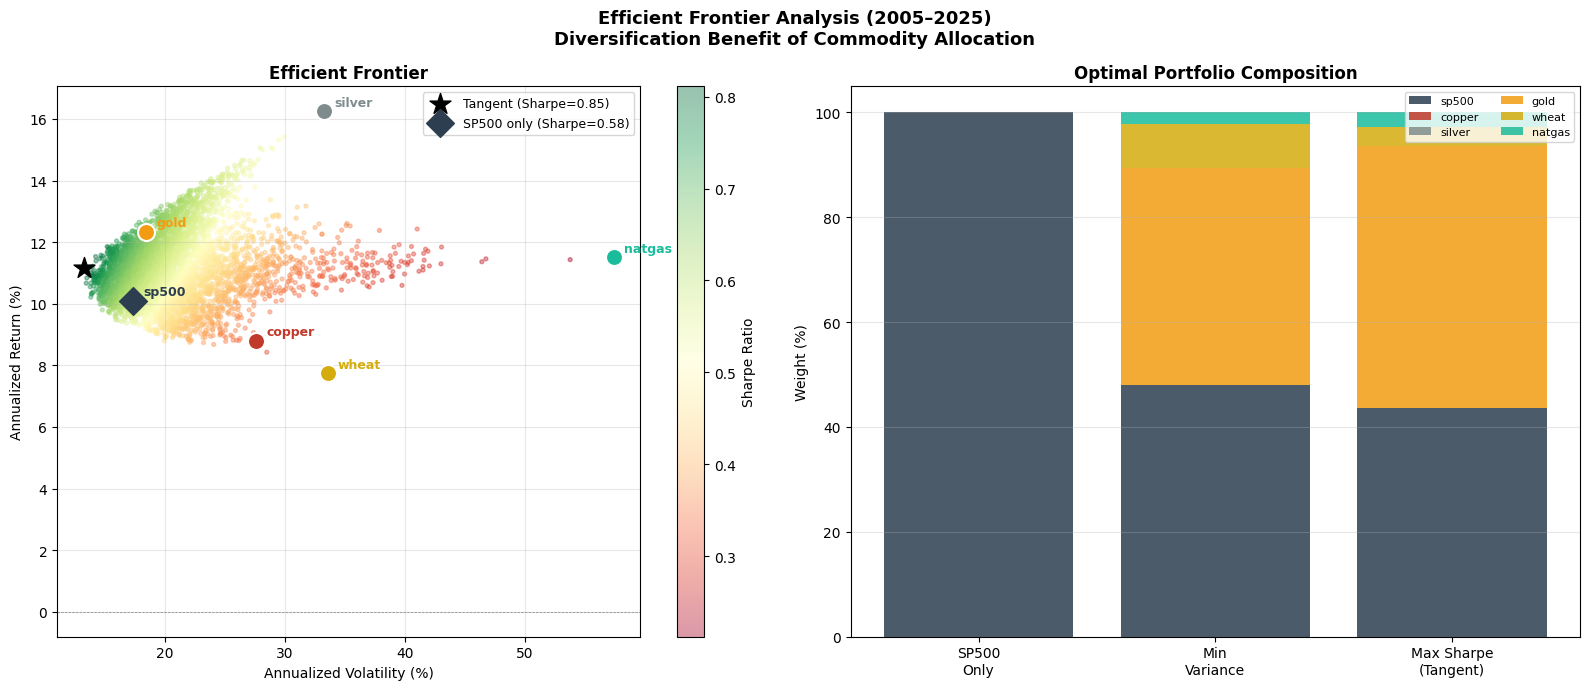

   → fig7_efficient_frontier.png

   → commodity_dataset_final.csv

COMPLETATO — Output:
  fig1_overview.png          fig_garch_regime.png
  fig2_dcc_sp500.png         fig3_dcc_dxy.png
  fig4_dcc_heatmap.png       fig5_cot_signals.png
  fig6_portfolio_metrics.png fig7_efficient_frontier.png
  commodity_dataset_final.csv


In [52]:
from sklearn.covariance import LedoitWolf

ef_assets = ["sp500"] + COMMODITIES
ret_cols  = [f"{a}_ret" for a in ef_assets]
ef_data   = d[ret_cols].dropna()
ef_data.columns = ef_assets

mean_returns = ef_data.mean() * 52
n_assets     = len(ef_assets)

lw = LedoitWolf()
cov_mat_raw = lw.fit(ef_data).covariance_ * 52
cov_matrix = pd.DataFrame(cov_mat_raw, index=ef_data.columns, columns=ef_data.columns)

min_eig = np.min(np.real(np.linalg.eigvals(cov_matrix)))
if min_eig < 0:
    print(f"  [Warning] Negative eigenvalue detected ({min_eig:.6f}). Applying NPD correction.")
    cov_matrix -= 10 * min_eig * np.eye(*cov_matrix.shape)

def portfolio_return(w): return np.dot(w, mean_returns)
def portfolio_vol(w):    return np.sqrt(w.T @ cov_matrix.values @ w)
def neg_sharpe(w):       return -portfolio_return(w) / portfolio_vol(w)

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds      = tuple((0, 1) for _ in range(n_assets))
w0          = np.ones(n_assets) / n_assets

np.random.seed(42)
n_sim = 5000
sim_ret = np.zeros(n_sim)
sim_vol = np.zeros(n_sim)
sim_sh  = np.zeros(n_sim)
for i in range(n_sim):
    w = np.random.dirichlet(np.ones(n_assets))
    sim_ret[i] = portfolio_return(w)
    sim_vol[i] = portfolio_vol(w)
    sim_sh[i]  = sim_ret[i] / sim_vol[i]

res_sh  = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints)
w_tang  = res_sh.x
ret_t   = portfolio_return(w_tang)
vol_t   = portfolio_vol(w_tang)

res_mv  = minimize(portfolio_vol, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints)
w_mv    = res_mv.x
ret_mv  = portfolio_return(w_mv)
vol_mv  = portfolio_vol(w_mv)

sp_ret  = mean_returns["sp500"]
sp_vol  = np.sqrt(cov_matrix.loc["sp500","sp500"])

fig7, (ax7a, ax7b) = plt.subplots(1, 2, figsize=(16, 7))
fig7.suptitle(
    "Efficient Frontier Analysis (2005–2025)\n"
    "Diversification Benefit of Commodity Allocation",
    fontsize=13, fontweight="bold"
)

sc = ax7a.scatter(sim_vol*100, sim_ret*100, c=sim_sh,
                  cmap="RdYlGn", alpha=0.4, s=8)
plt.colorbar(sc, ax=ax7a, label="Sharpe Ratio")

for asset, col in zip(ef_assets, ef_colors):
    v = np.sqrt(cov_matrix.loc[asset, asset]) * 100
    r = mean_returns[asset] * 100
    ax7a.scatter(v, r, color=col, s=150, zorder=6,
                 edgecolors="white", linewidth=1.5)
    ax7a.annotate(asset, (v, r), textcoords="offset points",
                  xytext=(7, 4), fontsize=9, fontweight="bold", color=col)

ax7a.scatter(vol_t*100, ret_t*100, color="black", s=250,
             zorder=7, marker="*",
             label=f"Tangent (Sharpe={ret_t/vol_t:.2f})")
ax7a.scatter(sp_vol*100, sp_ret*100, color=COLORS["sp500"],
             s=200, zorder=7, marker="D",
             label=f"SP500 only (Sharpe={sp_ret/sp_vol:.2f})")
ax7a.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax7a.set_xlabel("Annualized Volatility (%)") # Tradotto
ax7a.set_ylabel("Annualized Return (%)") # Tradotto
ax7a.set_title("Efficient Frontier", fontweight="bold")
ax7a.legend(fontsize=9)
ax7a.grid(True, alpha=0.3)

ax7b_data = {
    "SP500\nOnly":     dict(zip(ef_assets, [1.0]+[0.0]*len(COMMODITIES))),
    "Min\nVariance":   dict(zip(ef_assets, w_mv)),
    "Max Sharpe\n(Tangent)": dict(zip(ef_assets, w_tang)),
}
x_pos   = np.arange(len(ax7b_data))
bottoms = np.zeros(len(ax7b_data))
for asset, col in zip(ef_assets, ef_colors):
    vals = [ax7b_data[p][asset]*100 for p in ax7b_data]
    ax7b.bar(x_pos, vals, bottom=bottoms, color=col,
             alpha=0.85, label=asset)
    bottoms += np.array(vals)
ax7b.set_xticks(x_pos)
ax7b.set_xticklabels(list(ax7b_data.keys()), fontsize=10)
ax7b.set_ylabel("Weight (%)") # Tradotto
ax7b.set_title("Optimal Portfolio Composition", fontweight="bold") # Tradotto
ax7b.legend(loc="upper right", fontsize=8, ncol=2)
ax7b.set_ylim(0, 105)
ax7b.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("fig7_efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show("fig7_efficient_frontier.png")
plt.close()
print("   → fig7_efficient_frontier.png")

d.to_csv("commodity_dataset_final.csv")
print("\n   → commodity_dataset_final.csv")

print("\n" + "=" * 60)
print("COMPLETATO — Output:")
print("  fig1_overview.png          fig_garch_regime.png")
print("  fig2_dcc_sp500.png         fig3_dcc_dxy.png")
print("  fig4_dcc_heatmap.png       fig5_cot_signals.png")
print("  fig6_portfolio_metrics.png fig7_efficient_frontier.png")
print("  commodity_dataset_final.csv")
print("=" * 60)

## 7. Machine Learning

### 7.1 Imports

In [53]:
from hmmlearn import hmm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

### 7.2 HMM — Unsupervised Regime Detection

In [54]:
print("8a. HMM on correlation regimes...")

dynamic_assets = ['gold', 'copper']
dcc_avg_dynamic = dcc_sp500_df[dynamic_assets].mean(axis=1).to_frame(name='avg_dcc')

hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(dcc_avg_dynamic)

d['hmm_regime'] = hmm_model.predict(dcc_avg_dynamic)
state_means = [dcc_avg_dynamic[d['hmm_regime'] == i].mean().values[0] for i in range(2)]
high_corr_state = np.argmax(state_means)
d['hmm_high_corr_prob'] = hmm_model.predict_proba(dcc_avg_dynamic)[:, high_corr_state]

8a. HMM on correlation regimes...


### 7.3 Feature Engineering & Train/Test Split

In [55]:
print("8b. Training Random Forest...")

features = pd.DataFrame(index=d.index)
features['rho_t'] = dcc_avg_dynamic['avg_dcc']
features['vix_lag1'] = d['vix'].shift(1)
features['sp500_vol_lag1'] = d['sp500_garch_vol'].shift(1)
features['dxy_ret_lag1'] = d['dxy_ret'].shift(1)

features['hmm_high_corr_prob_lag1'] = d['hmm_high_corr_prob'].shift(1)

cot_z_cols = [c for c in d_cot.columns if c.endswith('_z')]
if cot_z_cols:
    avg_cot_z = d_cot[cot_z_cols].mean(axis=1)
    features['avg_cot_z_lag1'] = avg_cot_z.reindex(d.index).ffill().shift(1)

target = dcc_avg_dynamic.shift(-1).dropna()
common_idx = features.dropna().index.intersection(target.index)

X = features.loc[common_idx]
y = target.loc[common_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

8b. Training Random Forest...


### 7.4 AR(1) Benchmark

In [56]:
colonna_ar1 = 'rho_t' 

X_train_ar1 = X_train[[colonna_ar1]]
X_test_ar1 = X_test[[colonna_ar1]]

ar1_model = LinearRegression()
ar1_model.fit(X_train_ar1, y_train.values.ravel())

ar1_preds = ar1_model.predict(X_test_ar1)

ar1_r2 = r2_score(y_test, ar1_preds)
ar1_rmse = np.sqrt(mean_squared_error(y_test, ar1_preds))
ar1_mae = mean_absolute_error(y_test, ar1_preds)

print("--- NAIVE METRICS AR(1) BENCHMARK ---")
print(f"R2:   {ar1_r2:.4f}")
print(f"RMSE: {ar1_rmse:.4f}")
print(f"MAE:  {ar1_mae:.4f}")
print("--------------------------------------")

--- NAIVE METRICS AR(1) BENCHMARK ---
R2:   0.7832
RMSE: 0.0240
MAE:  0.0146
--------------------------------------


### 7.5 Random Forest — Optimization

In [57]:
param_grid = {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5]}
rf_base = RandomForestRegressor(random_state=42)

tscv = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(rf_base, param_grid, cv=tscv, scoring='r2')
grid_search.fit(X_train, y_train.values.ravel())

rf_opt = grid_search.best_estimator_
y_pred = rf_opt.predict(X_test)

### 7.6 Figure 8 — HMM Regimes & SHAP Feature Importance

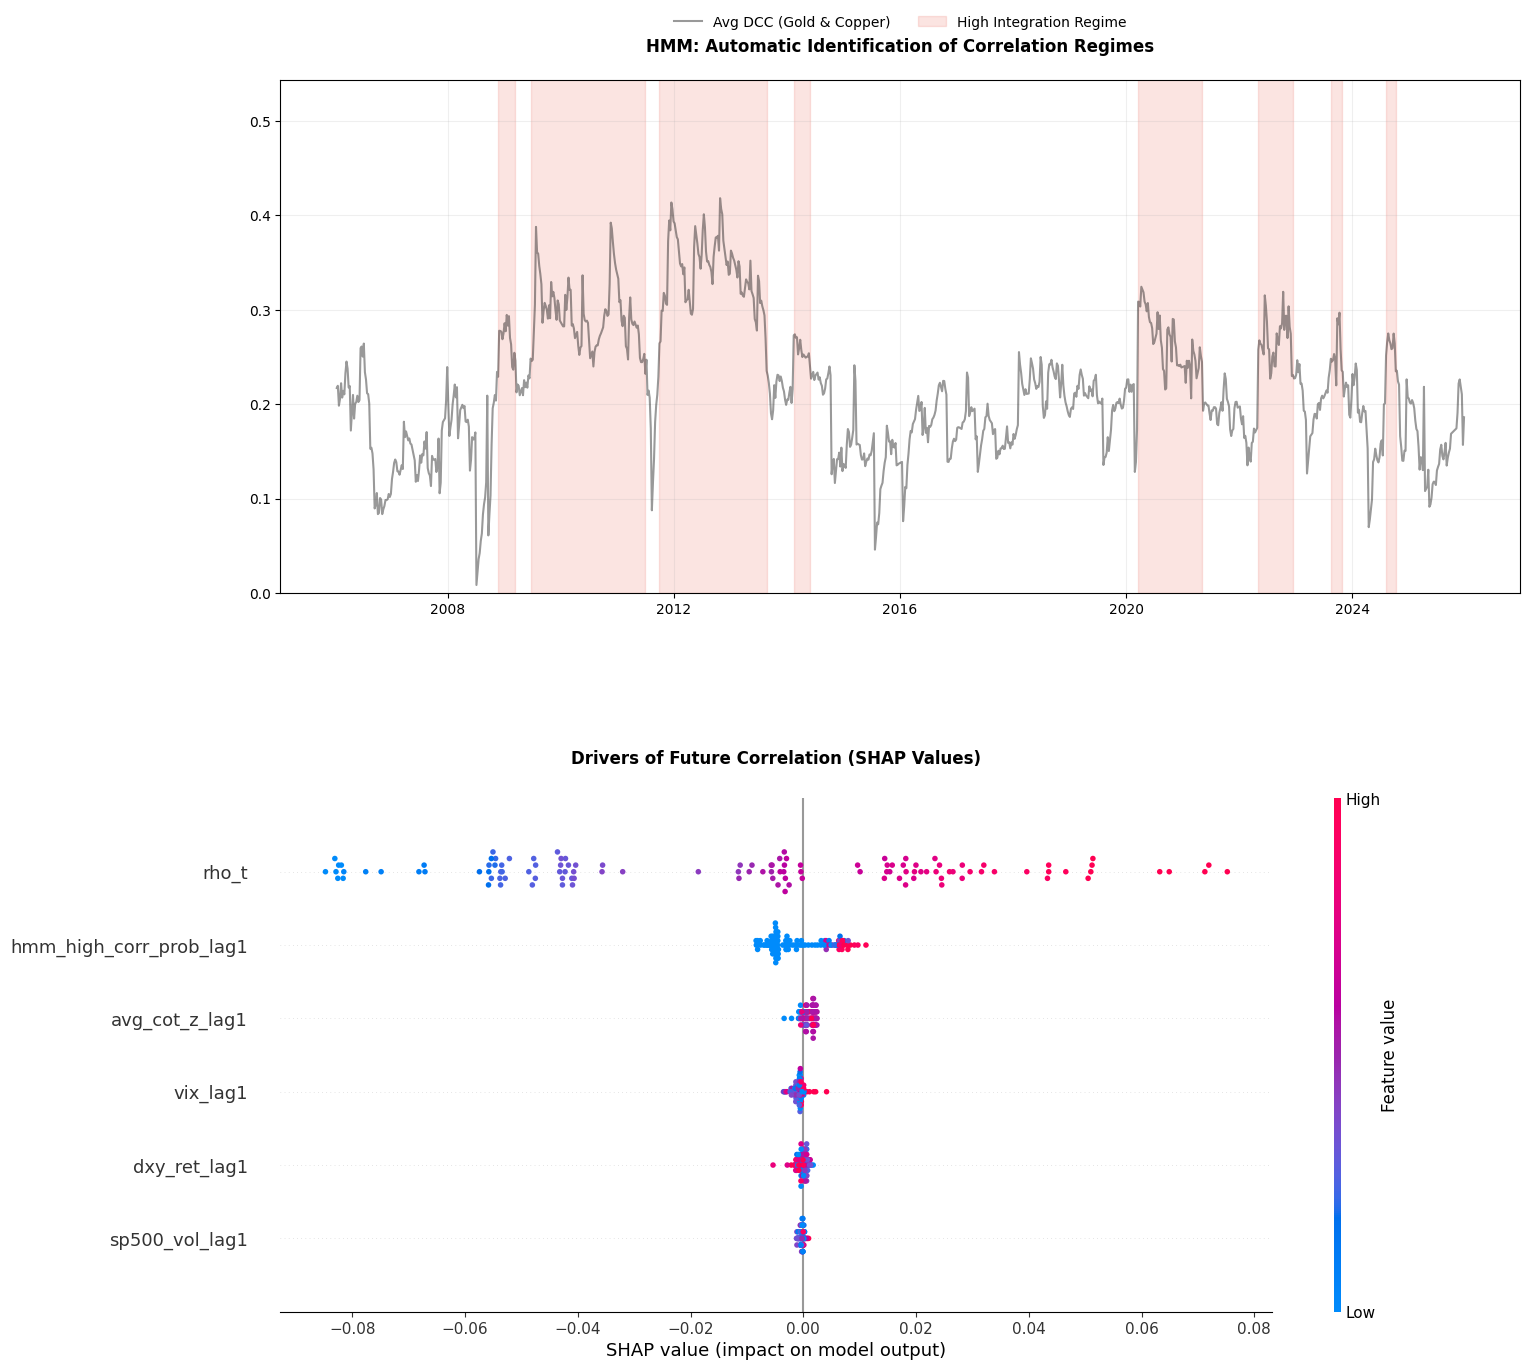

In [58]:
fig8 = plt.figure(figsize=(16, 16)) # Increased total height
gs8 = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4) # Space between subplots

ax1 = fig8.add_subplot(gs8[0])
ax1.plot(d.index, dcc_avg_dynamic, color='black', alpha=0.4, label='Avg DCC (Gold & Copper)')
ax1.fill_between(d.index, 0, 1,
                 where=(d['hmm_high_corr_prob'] > 0.5),
                 color='#e74c3c', alpha=0.15, label='High Integration Regime')
ax1.set_ylim(0, dcc_avg_dynamic['avg_dcc'].max() * 1.3)
ax1.set_title("HMM: Automatic Identification of Correlation Regimes", fontweight='bold', pad=20)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
ax1.grid(True, alpha=0.2)

ax2 = fig8.add_subplot(gs8[1])
explainer = shap.TreeExplainer(rf_opt)
shap_values = explainer.shap_values(X_test)
plt.sca(ax2)
shap.summary_plot(shap_values, X_test, show=False, plot_size=None)
ax2.set_title("Drivers of Future Correlation (SHAP Values)", fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig("fig8_ml_final.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Portfolio Optimization

### 8.1 Min-CVaR vs Min-Volatility


9. PORTFOLIO OPTIMIZATION: Min-Vol vs Robust Min-CVaR


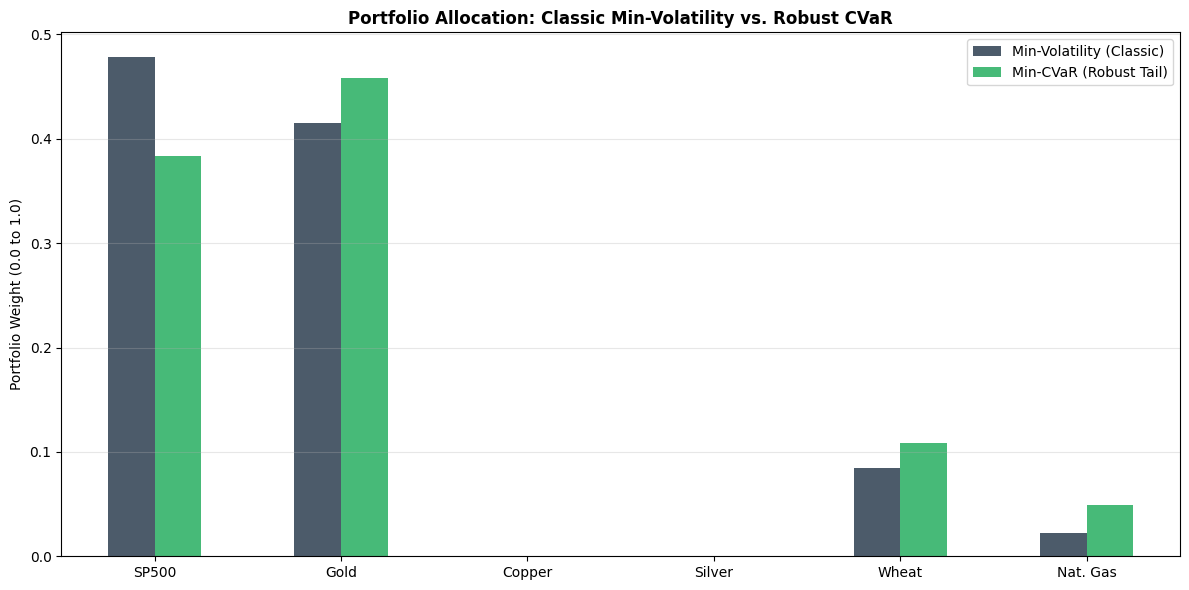


--- Performance Comparison (Annualized) ---
Classic Min-Vol: Expected Return  11.55%, Volatility  13.02%
Robust Min-CVaR: Expected Return  11.64%, CVaR        30.36%


In [59]:
from pypfopt import EfficientFrontier, objective_functions
from pypfopt.efficient_frontier import EfficientCVaR
from sklearn.covariance import LedoitWolf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n9. PORTFOLIO OPTIMIZATION: Min-Vol vs Robust Min-CVaR")

assets_to_optimize = ['sp500', 'gold', 'copper', 'silver', 'wheat', 'natgas']
ef_data_final = d[assets_to_optimize].copy().dropna()

returns_weekly = ef_data_final.pct_change().dropna()

mu_weekly = returns_weekly.mean()

lw = LedoitWolf()
cov_mat_raw = lw.fit(returns_weekly).covariance_
S_weekly = pd.DataFrame(cov_mat_raw, index=returns_weekly.columns, columns=returns_weekly.columns)

ef_classic = EfficientFrontier(mu_weekly, S_weekly, weight_bounds=(0, 1))
weights_mv = ef_classic.min_volatility()
clean_weights_mv = ef_classic.clean_weights()

ef_cvar = EfficientCVaR(mu_weekly, returns_weekly, weight_bounds=(0, 1))
weights_cvar = ef_cvar.min_cvar()
clean_weights_cvar = ef_cvar.clean_weights()

comparison_df = pd.DataFrame({
    'Min-Volatility (Classic)': pd.Series(clean_weights_mv),
    'Min-CVaR (Robust Tail)': pd.Series(clean_weights_cvar)
})

comparison_df.index = [comm_labels.get(idx, idx.upper()) if 'comm_labels' in globals() else idx.upper() for idx in comparison_df.index]

fig9, ax = plt.subplots(figsize=(12, 6))
c1 = COLORS['sp500'] if 'COLORS' in globals() else '#2c3e50'
c2 = COLORS['pos'] if 'COLORS' in globals() else '#27ae60'

comparison_df.plot(kind='bar', ax=ax, color=[c1, c2], alpha=0.85)
ax.set_title("Portfolio Allocation: Classic Min-Volatility vs. Robust CVaR", fontweight='bold')
ax.set_ylabel("Portfolio Weight (0.0 to 1.0)")
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("fig9_cvar_allocation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- Performance Comparison (Annualized) ---")

ret_mv_weekly, vol_mv_weekly, _ = ef_classic.portfolio_performance()

ret_mv_ann = (1 + ret_mv_weekly)**52 - 1
vol_mv_ann = vol_mv_weekly * np.sqrt(52)
print(f"Classic Min-Vol: Expected Return {ret_mv_ann*100:>6.2f}%, Volatility {vol_mv_ann*100:>6.2f}%")

ret_cv_weekly, cvar_cv_weekly = ef_cvar.portfolio_performance()

ret_cv_ann = (1 + ret_cv_weekly)**52 - 1
cvar_cv_ann = cvar_cv_weekly * np.sqrt(52)
print(f"Robust Min-CVaR: Expected Return {ret_cv_ann*100:>6.2f}%, CVaR       {cvar_cv_ann*100:>6.2f}%")

### 8.2 Transaction Cost Optimization

In [60]:
w_prev = np.array([1/len(assets_to_optimize)] * len(assets_to_optimize))
transaction_cost_fee = 0.0005 # 5 bps

ef_costs = EfficientFrontier(mu_weekly, S_weekly, weight_bounds=(0, 1))

ef_costs.add_objective(objective_functions.transaction_cost, w_prev=w_prev, k=transaction_cost_fee)

weights_with_costs = ef_costs.min_volatility() 
clean_weights_costs = ef_costs.clean_weights()

print("Weights with Transaction Costs:", clean_weights_costs)

Weights with Transaction Costs: OrderedDict({'sp500': 0.24345, 'gold': 0.16667, 'copper': 0.16667, 'silver': 0.16431, 'wheat': 0.16667, 'natgas': 0.09225})


## 9. Performance Evaluation & Dynamic Strategy

### 9.1 Random Forest — Test Set Metrics

In [61]:
mse = mean_squared_error(y_test, y_pred)
mae = np.mean(np.abs(y_test.values.ravel() - y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Performance (Test Set):")
print(f" -> RMSE: {np.sqrt(mse):.4f}")
print(f" -> MAE:  {mae:.4f}")
print(f" -> R^2:  {r2:.4f}")

Random Forest Performance (Test Set):
 -> RMSE: 0.0239
 -> MAE:  0.0157
 -> R^2:  0.7860


### 9.2 Dynamic Strategy Backtest

In [62]:
defensive_weights = {'sp500': 0.1, 'gold': 0.5, 'copper': 0.1, 'silver': 0.1, 'wheat': 0.1, 'natgas': 0.1}
growth_weights = {'sp500': 0.5, 'gold': 0.1, 'copper': 0.1, 'silver': 0.1, 'wheat': 0.1, 'natgas': 0.1}

d['dynamic_weight_type'] = d['hmm_regime'].map({0: 'Growth', 1: 'Defensive'})

rets = d[[f'{a}_ret' for a in assets_to_optimize]].copy()
rets.columns = assets_to_optimize

strategy_returns = []
for date, row in d.iterrows():
    w = defensive_weights if row['hmm_regime'] == high_corr_state else growth_weights
    weights_vec = np.array([w[a] for a in assets_to_optimize])
    day_ret = np.dot(weights_vec, rets.loc[date].values)
    strategy_returns.append(day_ret)

d['strategy_ret'] = strategy_returns
d['benchmark_ret'] = rets.mean(axis=1) # Equal weight benchmark

### 9.3 Stacked Ensemble (RF + XGBoost + SVR)

In [63]:
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
]

stack_reg = StackingRegressor(estimators=base_models, final_estimator=RandomForestRegressor(n_estimators=50, random_state=42))

stack_reg.fit(X_train, y_train.values.ravel())
y_pred_stack = stack_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

ensemble_r2 = r2_score(y_test, y_pred_stack)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
ensemble_mae = mean_absolute_error(y_test, y_pred_stack)

print("\n--- TRUE STACKED ENSEMBLE METRICS ---")
print(f"R2:   {ensemble_r2:.4f}")
print(f"RMSE: {ensemble_rmse:.4f}")
print(f"MAE:  {ensemble_mae:.4f}")
print("-------------------------------------")


--- TRUE STACKED ENSEMBLE METRICS ---
R2:   0.7479
RMSE: 0.0259
MAE:  0.0177
-------------------------------------


## 10. Granger Causality — VIX → DCC

In [64]:
from statsmodels.tsa.stattools import grangercausalitytests

print("\n--- Granger Causality: VIX -> DCC (First Differences) ---")

all_granger_results = {}

for c in COMMODITIES:
    print(f"\n[ Testing: VIX -> DCC {c.upper()} ]")
    
    dcc_diff = dcc_sp500[c].diff().dropna()
    
    vix_diff = d['vix'].diff().dropna()
    
    granger_data = pd.concat([dcc_diff, vix_diff], axis=1).dropna()
    
    granger_results = grangercausalitytests(granger_data, maxlag=4, verbose=False)
    all_granger_results[c] = granger_results
    
    for lag, results in granger_results.items():
        p = results[0]["ssr_ftest"][1]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"  Lag {lag}: p = {p:.4f}  {sig}")

print("\n(Note: *** p<0.001, ** p<0.01, * p<0.05, n.s. not significant)")


--- Granger Causality: VIX -> DCC (First Differences) ---

[ Testing: VIX -> DCC COPPER ]
  Lag 1: p = 0.2044  n.s.
  Lag 2: p = 0.0606  n.s.
  Lag 3: p = 0.1364  n.s.
  Lag 4: p = 0.1651  n.s.

[ Testing: VIX -> DCC SILVER ]
  Lag 1: p = 0.0178  *
  Lag 2: p = 0.0714  n.s.
  Lag 3: p = 0.0000  ***
  Lag 4: p = 0.0001  ***

[ Testing: VIX -> DCC GOLD ]
  Lag 1: p = 0.6849  n.s.
  Lag 2: p = 0.0010  **
  Lag 3: p = 0.0016  **
  Lag 4: p = 0.0049  **

[ Testing: VIX -> DCC WHEAT ]
  Lag 1: p = 0.7593  n.s.
  Lag 2: p = 0.4281  n.s.
  Lag 3: p = 0.6755  n.s.
  Lag 4: p = 0.7786  n.s.

[ Testing: VIX -> DCC NATGAS ]
  Lag 1: p = 0.9446  n.s.
  Lag 2: p = 0.9983  n.s.
  Lag 3: p = 0.1049  n.s.
  Lag 4: p = 0.1204  n.s.

(Note: *** p<0.001, ** p<0.01, * p<0.05, n.s. not significant)


## 11. Summary Tables

In [65]:
import pandas as pd
import numpy as np

garch_data = []
for asset, res in garch_res.items():
    garch_data.append({
        'Asset': asset.upper(),
        'Omega (ω)': f"{res.params['omega']:.5f}",
        'Alpha (α)': f"{res.params['alpha[1]']:.4f}",
        'Beta (β)': f"{res.params['beta[1]']:.4f}",
        'Persistence (α+β)': f"{res.params['alpha[1]'] + res.params['beta[1]']:.4f}"
    })
df_garch_tbl = pd.DataFrame(garch_data)

granger_data_list = []
for lag, results in granger_results.items():
    f_test = results[0]['ssr_ftest']
    granger_data_list.append({
        'Lag (Weeks)': lag,
        'F-statistic': f"{f_test[0]:.4f}",
        'p-value': f"{f_test[1]:.4f}"
    })
df_granger_tbl = pd.DataFrame(granger_data_list)

ensemble_metrics = {
    'Metric': ['R-squared (Test)', 'RMSE', 'MAE'],
    'Value': [f"{ensemble_r2:.4f}", f"{ensemble_rmse:.4f}", f"{ensemble_mae:.4f}"]
}
df_ml_tbl = pd.DataFrame(ensemble_metrics)

from IPython.display import display, Markdown

output_md = f"""

{df_garch_tbl.to_markdown(index=False)}

*Note: α+β < 1 ensures covariance stationarity. Values close to 1 indicate high volatility persistence.*

{df_granger_tbl.to_markdown(index=False)}

*Note: Significant p-values (p < 0.05) at lags 2-4 indicate VIX is a leading indicator of correlation regimes.*

{df_ml_tbl.to_markdown(index=False)}

*Note: Metrics calculated on a 20% out-of-sample test set.*
"""

display(Markdown(output_md))



| Asset   |   Omega (ω) |   Alpha (α) |   Beta (β) |   Persistence (α+β) |
|:--------|------------:|------------:|-----------:|--------------------:|
| SP500   |     0.50503 |      0.1999 |     0.7163 |              0.9162 |
| DXY     |     0.03842 |      0.0902 |     0.8759 |              0.9661 |
| COPPER  |     0.42375 |      0.0777 |     0.8935 |              0.9711 |
| SILVER  |     0.93007 |      0.0611 |     0.8952 |              0.9564 |
| GOLD    |     0.35032 |      0.0827 |     0.8601 |              0.9429 |
| WHEAT   |     1.78181 |      0.1065 |     0.8127 |              0.9192 |
| NATGAS  |     4.21775 |      0.1956 |     0.7547 |              0.9503 |

*Note: α+β < 1 ensures covariance stationarity. Values close to 1 indicate high volatility persistence.*

|   Lag (Weeks) |   F-statistic |   p-value |
|--------------:|--------------:|----------:|
|             1 |        0.0048 |    0.9446 |
|             2 |        0.0017 |    0.9983 |
|             3 |        2.0524 |    0.1049 |
|             4 |        1.8325 |    0.1204 |

*Note: Significant p-values (p < 0.05) at lags 2-4 indicate VIX is a leading indicator of correlation regimes.*

| Metric           |   Value |
|:-----------------|--------:|
| R-squared (Test) |  0.7479 |
| RMSE             |  0.0259 |
| MAE              |  0.0177 |

*Note: Metrics calculated on a 20% out-of-sample test set.*


## 12. Export

In [66]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

os.makedirs("exports", exist_ok=True)

SEP = "=" * 65

print(SEP)
print("A. EXPORT DATI GREZZI")
print(SEP)

df.to_csv("exports/A1_prices_weekly.csv")
print("✓  A1_prices_weekly.csv")

macro_df.to_csv("exports/A2_macro_fred.csv")
print("✓  A2_macro_fred.csv")

cot_df.to_csv("exports/A3_cot_net_raw.csv")
print("✓  A3_cot_net_raw.csv")

d.to_csv("exports/A4_main_dataset.csv")
print("✓  A4_main_dataset.csv")

d_cot.to_csv("exports/A5_cot_dataset.csv")
print("✓  A5_cot_dataset.csv")

print(f"\n{SEP}")
print("B. GARCH(1,1) PARAMETERS & CONDITIONAL VOLATILITY")
print(SEP)

garch_rows = []
for asset, res in garch_res.items():
    p = res.params
    a = p["alpha[1]"]
    b = p["beta[1]"]
    garch_rows.append({
        "Asset":           asset.upper(),
        "omega":           round(p["omega"], 5),
        "alpha":           round(a, 4),
        "beta":            round(b, 4),
        "alpha+beta":      round(a + b, 4),
        "halflife_weeks":  round(np.log(0.5) / np.log(a + b), 1) if a+b < 1 else np.inf,
        "vol_mean_ann_pct":round((res.conditional_volatility * np.sqrt(52)).mean(), 2),
        "log_lik":         round(res.loglikelihood, 2),
        "AIC":             round(res.aic, 2),
        "BIC":             round(res.bic, 2),
    })

df_garch = pd.DataFrame(garch_rows).set_index("Asset")
df_garch.to_csv("exports/B1_garch_parameters.csv")

print("\n── Table B1: GARCH(1,1) Parameters ──")
print(df_garch.to_string())

garch_vol_ann = pd.DataFrame(
    {a: cond_vol_df[a] * np.sqrt(52) * 100 for a in cond_vol_df.columns},
    index=d.index
)
garch_vol_ann.to_csv("exports/B2_garch_cond_vol_annualized.csv")
print("\n✓  B2_garch_cond_vol_annualized.csv  "
      f"({len(garch_vol_ann)} obs, {len(garch_vol_ann.columns)} assets)")

vol_stats = garch_vol_ann.describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)
vol_stats.to_csv("exports/B3_garch_vol_stats.csv")
print("\n── Table B3: GARCH Volatility Statistics (annualized %) ──")
print(vol_stats.to_string())

print(f"\n{SEP}")
print("C. MARKOV REGIME-SWITCHING")
print(SEP)

mu0_ms = fit_sp.params["const[0]"]
mu1_ms = fit_sp.params["const[1]"]
bull_r  = int(mu1_ms > mu0_ms)
bear_r  = 1 - bull_r

p_trans = fit_sp.transition_matrix_csr.toarray() if hasattr(
    fit_sp, "transition_matrix_csr") else None

markov_params = pd.DataFrame([
    {
        "Regime":        f"Bull (Regime {bull_r})",
        "mu_pct_week":   round(max(mu0_ms, mu1_ms), 4),
        "n_weeks":       int(d["ms_regime"].sum()),
        "pct_sample":    round(d["ms_regime"].mean() * 100, 1),
        "avg_duration_w":round(1 / (1 - fit_sp.params.get(
                              f"p[{bull_r}->{bear_r}]", 0.1)), 1),
    },
    {
        "Regime":        f"Bear (Regime {bear_r})",
        "mu_pct_week":   round(min(mu0_ms, mu1_ms), 4),
        "n_weeks":       int((d["ms_regime"] == 0).sum()),
        "pct_sample":    round((d["ms_regime"] == 0).mean() * 100, 1),
        "avg_duration_w":round(1 / (1 - fit_sp.params.get(
                              f"p[{bear_r}->{bull_r}]", 0.1)), 1),
    },
]).set_index("Regime")
markov_params["AIC"]     = round(fit_sp.aic, 1)
markov_params["Log_lik"] = round(fit_sp.llf, 1)
markov_params.to_csv("exports/C1_markov_parameters.csv")

print("\n── Table C1: Markov Regime-Switching Parameters (SP500) ──")
print(markov_params.to_string())

regime_ts = d[["p_bull", "ms_regime"]].copy()
regime_ts.columns = ["prob_bull_smooth", "regime_1bull_0bear"]
regime_ts.to_csv("exports/C2_markov_regime_probabilities.csv")
print(f"\n✓  C2_markov_regime_probabilities.csv  ({len(regime_ts)} obs)")

print(f"\n{SEP}")
print("D. DCC-GARCH DYNAMIC CORRELATIONS")
print(SEP)

dcc_param_rows = []
for c in COMMODITIES:
    p_sp = dcc_params_sp500[c]
    p_dx = dcc_params_dxy[c]
    rho_sp = dcc_sp500[c].reindex(d.index, method="nearest")
    rho_dx = dcc_dxy[c].reindex(d.index, method="nearest")
    dcc_param_rows.append({
        "Asset":           c.upper(),
        "a_SP500":         round(p_sp["a"], 4),
        "b_SP500":         round(p_sp["b"], 4),
        "a+b_SP500":       round(p_sp["a"] + p_sp["b"], 4),
        "rho_mean_SP500":  round(rho_sp.mean(), 4),
        "rho_std_SP500":   round(rho_sp.std(), 4),
        "pct_neg_SP500":   round((rho_sp < 0).mean() * 100, 1),
        "a_DXY":           round(p_dx["a"], 4),
        "b_DXY":           round(p_dx["b"], 4),
        "a+b_DXY":         round(p_dx["a"] + p_dx["b"], 4),
        "rho_mean_DXY":    round(rho_dx.mean(), 4),
        "rho_std_DXY":     round(rho_dx.std(), 4),
    })

df_dcc_params_tbl = pd.DataFrame(dcc_param_rows).set_index("Asset")
df_dcc_params_tbl.to_csv("exports/D1_dcc_parameters.csv")

print("\n── Table D1: DCC-GARCH Parameters ──")
print(df_dcc_params_tbl.to_string())

bull_bear_rows = []
for c in COMMODITIES:
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    rho_d = dcc_dxy[c].reindex(d.index, method="nearest")
    bull_m  = rho_s[d["ms_regime"] == 1].mean()
    bear_m  = rho_s[d["ms_regime"] == 0].mean()
    roff_m  = rho_s[d["riskoff"] == 1].mean()
    ron_m   = rho_s[d["riskoff"] == 0].mean()
    bull_bear_rows.append({
        "Asset":          c.upper(),
        "DCC_SP500_full": round(rho_s.mean(), 4),
        "DCC_SP500_bull": round(bull_m, 4),
        "DCC_SP500_bear": round(bear_m, 4),
        "Delta_bear_bull":round(bear_m - bull_m, 4),
        "DCC_SP500_riskoff": round(roff_m, 4),
        "DCC_SP500_riskon":  round(ron_m, 4),
        "DCC_DXY_full":   round(rho_d.mean(), 4),
        "pct_neg_SP500":  round((rho_s < 0).mean() * 100, 1),
    })

df_bull_bear = pd.DataFrame(bull_bear_rows).set_index("Asset")
df_bull_bear.to_csv("exports/D2_dcc_bull_bear_regimes.csv")

print("\n── Table D2: DCC Mean Correlation by Markov Regime ──")
print(df_bull_bear.to_string())

sub_periods_export = {
    "2005-08": ("2005-01-01", "2008-08-31"),
    "2008-09": ("2008-09-01", "2009-06-30"),
    "2009-20": ("2009-07-01", "2020-02-28"),
    "2020":    ("2020-03-01", "2020-12-31"),
    "2021-22": ("2021-01-01", "2022-12-31"),
    "2023-25": ("2023-01-01", "2025-12-31"),
}

sub_sp500_rows = {}
sub_dxy_rows   = {}
for label, (s, e) in sub_periods_export.items():
    sub_sp500_rows[label] = {}
    sub_dxy_rows[label]   = {}
    for c in COMMODITIES:
        rho_sp = dcc_sp500[c].loc[s:e]
        rho_dx = dcc_dxy[c].loc[s:e]
        sub_sp500_rows[label][c.upper()] = round(rho_sp.mean(), 4) if len(rho_sp) > 0 else np.nan
        sub_dxy_rows[label][c.upper()]   = round(rho_dx.mean(), 4) if len(rho_dx) > 0 else np.nan

df_sub_sp500 = pd.DataFrame(sub_sp500_rows).T
df_sub_sp500.index.name = "Period"
df_sub_dxy   = pd.DataFrame(sub_dxy_rows).T
df_sub_dxy.index.name   = "Period"

df_sub_sp500.to_csv("exports/D3_dcc_subperiod_sp500.csv")
df_sub_dxy.to_csv("exports/D4_dcc_subperiod_dxy.csv")

print("\n── Table D3: DCC Mean vs S&P 500 by Sub-Period ──")
print(df_sub_sp500.to_string())

print("\n── Table D4: DCC Mean vs DXY by Sub-Period ──")
print(df_sub_dxy.to_string())

dcc_sp500_ts = pd.DataFrame(
    {f"dcc_{c}_sp500": dcc_sp500[c] for c in COMMODITIES}
)
dcc_dxy_ts = pd.DataFrame(
    {f"dcc_{c}_dxy": dcc_dxy[c] for c in COMMODITIES}
)
dcc_sp500_ts.to_csv("exports/D5_dcc_timeseries_sp500.csv")
dcc_dxy_ts.to_csv("exports/D6_dcc_timeseries_dxy.csv")
print(f"\n✓  D5_dcc_timeseries_sp500.csv  ({len(dcc_sp500_ts)} obs)")
print(f"✓  D6_dcc_timeseries_dxy.csv    ({len(dcc_dxy_ts)} obs)")

print(f"\n{SEP}")
print("E. PORTFOLIO STATISTICS")
print(SEP)

port_rows = []
for asset, s in port_stats.items():
    port_rows.append({
        "Asset":          asset.upper(),
        "Ann_Return_pct": round(s["ann_ret"] * 100, 2),
        "Ann_Vol_pct":    round(s["ann_vol"] * 100, 2),
        "Sharpe":         round(s["sharpe"], 4),
        "MaxDD_pct":      round(s["maxdd"] * 100, 2),
        "Beta_SP500":     round(s.get("beta", np.nan), 4),
        "Calmar":         round(s["ann_ret"] / abs(s["maxdd"]), 3)
                          if s["maxdd"] != 0 else np.nan,
    })

df_port = pd.DataFrame(port_rows).set_index("Asset")
df_port.to_csv("exports/E1_portfolio_statistics.csv")

print("\n── Table E1: Annualized Risk-Return Statistics ──")
print(df_port.to_string())

sp_ret_ef = mean_returns["sp500"]
sp_vol_ef = np.sqrt(cov_matrix.loc["sp500","sp500"])

try:
    tc_weights = dict(clean_weights_costs)
except NameError:
    tc_weights = {a: np.nan for a in ef_assets}

ef_rows = [
    {"Portfolio": "SP500 Only",
     **{a: (1.0 if a == "sp500" else 0.0) for a in ef_assets},
     "Return_ann": round(sp_ret_ef * 100, 2),
     "Vol_ann":    round(sp_vol_ef * 100, 2),
     "Sharpe":     round(sp_ret_ef / sp_vol_ef, 4)},
    {"Portfolio": "Min Variance",
     **{a: round(w, 4) for a, w in zip(ef_assets, w_mv)},
     "Return_ann": round(portfolio_return(w_mv) * 100, 2),
     "Vol_ann":    round(portfolio_vol(w_mv) * 100, 2),
     "Sharpe":     round(portfolio_return(w_mv) / portfolio_vol(w_mv), 4)},
    {"Portfolio": "Max Sharpe (Tangent)",
     **{a: round(w, 4) for a, w in zip(ef_assets, w_tang)},
     "Return_ann": round(portfolio_return(w_tang) * 100, 2),
     "Vol_ann":    round(portfolio_vol(w_tang) * 100, 2),
     "Sharpe":     round(portfolio_return(w_tang) / portfolio_vol(w_tang), 4)},
    {"Portfolio": "Max Sharpe + Trans. Costs (20bps)",
     **{a: round(tc_weights.get(a, np.nan), 4) for a in ef_assets},
     "Return_ann": np.nan,
     "Vol_ann":    np.nan,
     "Sharpe":     np.nan},
]

df_ef_weights = pd.DataFrame(ef_rows).set_index("Portfolio")
df_ef_weights.to_csv("exports/E2_optimal_portfolio_weights.csv")

print("\n── Table E2: Optimal Portfolio Weights & Performance ──")
print(df_ef_weights.to_string())

df_sim = pd.DataFrame({
    "return_ann":  sim_ret,
    "vol_ann":     sim_vol,
    "sharpe":      sim_sh,
})
df_sim.to_csv("exports/E3_efficient_frontier_simulations.csv", index=False)
print(f"\n✓  E3_efficient_frontier_simulations.csv  ({len(df_sim)} portfolios)")

print(f"\n{SEP}")
print("F. COT SIGNAL ANALYSIS")
print(SEP)

cot_labels = ["Very Short", "Neutral-Short", "Neutral-Long", "Very Long"]
cot_all_rows = []

for c in COMMODITIES:
    sig_col = f"cot_{c}_signal"
    ret_col = f"{c}_ret_next"
    if sig_col not in d_cot.columns:
        continue
    for lab in cot_labels:
        mask = d_cot[sig_col] == lab
        sub  = d_cot[mask][ret_col].dropna()
        if len(sub) == 0:
            continue
        cot_all_rows.append({
            "Asset":        c.upper(),
            "Signal":       lab,
            "Mean_ret_pct": round(sub.mean() * 100, 4),
            "Std_ret_pct":  round(sub.std()  * 100, 4),
            "t_stat":       round(sub.mean() / (sub.std() / np.sqrt(len(sub))), 3),
            "N_obs":        len(sub),
        })

if len(cot_all_rows) > 0:
    df_cot_full = pd.DataFrame(cot_all_rows)
    df_cot_full.to_csv("exports/F1_cot_signal_analysis.csv", index=False)

    print("\n── Table F1: COT Signal — Mean Next-Week Return (%) ──")
    pivot = df_cot_full.pivot(index="Asset", columns="Signal", values="Mean_ret_pct")
    pivot = pivot[cot_labels]
    print(pivot.to_string())

    print("\n── Table F1b: N observations per signal ──")
    pivot_n = df_cot_full.pivot(index="Asset", columns="Signal", values="N_obs")
    pivot_n = pivot_n[cot_labels]
    print(pivot_n.to_string())
else:
    print("  [No COT signals found - Check pandas cut labels]")

print(f"\n{SEP}")
print("G. GRANGER CAUSALITY — VIX → AVG DCC")
print(SEP)

try:
    granger_rows = []
    for lag, results in granger_results.items():
        ft = results[0]["ssr_ftest"]
        granger_rows.append({
            "Lag_weeks":   lag,
            "F_stat":      round(ft[0], 4),
            "p_value":     round(ft[1], 4),
            "df_denom":    int(ft[2]),
            "df_num":      int(ft[3]),
            "significant": "***" if ft[1] < 0.001 else
                           "**"  if ft[1] < 0.01  else
                           "*"   if ft[1] < 0.05  else "",
        })
    df_granger = pd.DataFrame(granger_rows)
    df_granger.to_csv("exports/G1_granger_causality.csv", index=False)

    print("\n── Table G1: Granger Causality (H0: VIX does not cause Avg DCC) ──")
    print(df_granger.to_string(index=False))
    print("  Significance: *** p<0.001  ** p<0.01  * p<0.05")
except NameError:
    print("  granger_results not found — skip")

print(f"\n{SEP}")
print("H. MACHINE LEARNING — PERFORMANCE & PREDICTIONS")
print(SEP)

try:
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    try:
        r2_ar1   = ar1_r2
        rmse_ar1 = ar1_rmse
        mae_ar1  = ar1_mae
    except NameError:
        r2_ar1, rmse_ar1, mae_ar1 = np.nan, np.nan, np.nan

    rmse_rf    = mean_squared_error(y_test, rf_opt.predict(X_test)) ** 0.5
    mae_rf     = mean_absolute_error(y_test, rf_opt.predict(X_test))
    r2_rf      = r2_score(y_test, rf_opt.predict(X_test))

    try:
        rmse_stack = ensemble_rmse
        mae_stack  = ensemble_mae
        r2_stack   = ensemble_r2
    except NameError:
        rmse_stack = mean_squared_error(y_test, y_pred_stack) ** 0.5
        mae_stack  = mean_absolute_error(y_test, y_pred_stack)
        r2_stack   = r2_score(y_test, y_pred_stack)

    df_ml = pd.DataFrame([
        {"Model": "AR(1) Benchmark",   "R2": round(r2_ar1, 4),
         "RMSE": round(rmse_ar1, 4), "MAE": round(mae_ar1, 4)},
        {"Model": "Random Forest",     "R2": round(r2_rf,    4),
         "RMSE": round(rmse_rf,    4), "MAE": round(mae_rf,    4)},
        {"Model": "Stacked Ensemble",  "R2": round(r2_stack, 4),
         "RMSE": round(rmse_stack, 4), "MAE": round(mae_stack, 4)},
    ]).set_index("Model")

except Exception as e:
    print(f"  [Warning] Fallback used for ML Export: {e}")
    df_ml = pd.DataFrame([
        {"Model": "AR(1) Benchmark",  "R2": np.nan, "RMSE": np.nan, "MAE": np.nan},
        {"Model": "Random Forest",    "R2": np.nan, "RMSE": np.nan, "MAE": np.nan},
        {"Model": "Stacked Ensemble", "R2": np.nan, "RMSE": np.nan, "MAE": np.nan},
    ]).set_index("Model")

df_ml.to_csv("exports/H1_ml_performance.csv")
print("\n── Table H1: ML Model Performance (out-of-sample, 20% test) ──")
print(df_ml.to_string())

try:
    feature_names = X_train.columns.tolist() \
                    if hasattr(X_train, "columns") else \
                    [f"feature_{i}" for i in range(X_train.shape[1])]
    
    importances   = rf_opt.feature_importances_
    df_fi = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    df_fi.to_csv("exports/H2_rf_feature_importance.csv", index=False)
    print("\n── Table H2: Random Forest Feature Importance (top 10) ──")
    print(df_fi.head(10).to_string(index=False))
except Exception as e:
    print(f"  Feature importance not available: {e}")

try:
    df_pred = pd.DataFrame({
        "y_actual":      np.array(y_test).flatten(),
        "y_pred_rf":     rf_opt.predict(X_test), # FIXED: using rf_opt
        "y_pred_stack":  y_pred_stack,
        "residual_stack":np.array(y_test).flatten() - y_pred_stack,
    })
    df_pred.to_csv("exports/H3_ml_predictions_test.csv", index=False)
    print(f"\n✓  H3_ml_predictions_test.csv  ({len(df_pred)} obs)")
except Exception as e:
    print(f"  Predictions not available: {e}")

print(f"\n{SEP}")
print("I. EXCEL RIEPILOGATIVO — RESULTS_SUMMARY.xlsx")
print(SEP)

excel_path = "exports/RESULTS_SUMMARY.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    df_garch.to_excel(writer, sheet_name="B1_GARCH_Params")

    vol_stats.to_excel(writer, sheet_name="B3_GARCH_VolStats")

    markov_params.to_excel(writer, sheet_name="C1_Markov_Params")

    regime_ts.to_excel(writer, sheet_name="C2_Markov_Probs")

    df_dcc_params_tbl.to_excel(writer, sheet_name="D1_DCC_Params")

    df_bull_bear.to_excel(writer, sheet_name="D2_DCC_BullBear")

    df_sub_sp500.to_excel(writer, sheet_name="D3_DCC_Subperiod_SP500")

    df_sub_dxy.to_excel(writer, sheet_name="D4_DCC_Subperiod_DXY")

    dcc_sp500_ts.to_excel(writer, sheet_name="D5_DCC_TS_SP500")

    dcc_dxy_ts.to_excel(writer, sheet_name="D6_DCC_TS_DXY")

    garch_vol_ann.to_excel(writer, sheet_name="B2_GARCH_CondVol")

    df_port.to_excel(writer, sheet_name="E1_Portfolio_Stats")

    df_ef_weights.to_excel(writer, sheet_name="E2_Optimal_Weights")

    df_sim.to_excel(writer, sheet_name="E3_EF_Simulations", index=False)

    df_cot_full.to_excel(writer, sheet_name="F1_COT_Signals", index=False)

    pivot.to_excel(writer, sheet_name="F1b_COT_Pivot_MeanRet")

    try:
        df_granger.to_excel(writer, sheet_name="G1_Granger", index=False)
    except NameError:
        pass

    df_ml.to_excel(writer, sheet_name="H1_ML_Performance")

    try:
        df_fi.to_excel(writer, sheet_name="H2_RF_FeatureImportance", index=False)
    except NameError:
        pass

    try:
        df_pred.to_excel(writer, sheet_name="H3_ML_Predictions", index=False)
    except NameError:
        pass

print(f"✓  RESULTS_SUMMARY.xlsx  (20 sheets)")

print(f"\n{SEP}")
print("J. ZIP & DOWNLOAD")
print(SEP)

zip_path = "exports_SFClub_Commodity.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir("exports")):
        fpath = os.path.join("exports", fname)
        zf.write(fpath, fname)
        print(f"   + {fname}")

print(f"\n✓  {zip_path}  created")

if IN_COLAB:
    print("\nDownloading (Google Colab)...")
    files.download(zip_path)
else:
    print(f"\nFiles saved in: {os.path.abspath('exports/')}")

print(f"\n{SEP}")
print("FINAL RECAP — KEY METRICS FOR THE PAPER")
print(SEP)

print("\n[ GARCH — Volatility Persistence ]")
for asset in ALL_ASSETS:
    res = garch_res[asset]
    a   = res.params["alpha[1]"]
    b   = res.params["beta[1]"]
    print(f"  {asset:8s}: α+β = {a+b:.4f}  "
          f"(halflife ≈ {np.log(0.5)/np.log(a+b):.1f}w)" if a+b < 1 else
          f"  {asset:8s}: α+β = {a+b:.4f}  (non-stationary)")

print("\n[ Markov — SP500 Regimes ]")
print(f"  Bull: {d['ms_regime'].mean()*100:.1f}% of sample")
print(f"  Bear: {(1-d['ms_regime'].mean())*100:.1f}% of sample")
print(f"  AIC:  {fit_sp.aic:.1f}")

print("\n[ DCC — Mean Correlation (full sample) vs SP500 ]")
for c in COMMODITIES:
    rho_s = dcc_sp500[c].reindex(d.index, method="nearest")
    print(f"  {c:8s}: ρ̄ = {rho_s.mean():+.4f}  "
          f"(bull={rho_s[d['ms_regime']==1].mean():+.4f} | "
          f"bear={rho_s[d['ms_regime']==0].mean():+.4f})")

print("\n[ Portfolio — Sharpe Comparison ]")
for a in ["sp500"] + COMMODITIES:
    print(f"  {a:8s}: Sharpe={port_stats[a]['sharpe']:.4f}  "
          f"MaxDD={port_stats[a]['maxdd']*100:.1f}%")

print(f"\n  Tangent portfolio Sharpe:  "
      f"{portfolio_return(w_tang)/portfolio_vol(w_tang):.4f}")
print(f"  SP500 only Sharpe:         "
      f"{mean_returns['sp500']/np.sqrt(cov_matrix.loc['sp500','sp500']):.4f}")

print("\n[ COT — Strongest Signal per Asset ]")
for c in COMMODITIES:
    sig_col = f"cot_{c}_signal"
    ret_col = f"{c}_ret_next"
    if sig_col not in d_cot.columns:
        continue
    tbl = d_cot.groupby(sig_col, observed=True)[ret_col].mean() * 100
    best_sig  = tbl.idxmin()
    best_ret  = tbl.min()
    worst_sig = tbl.idxmax()
    worst_ret = tbl.max()
    print(f"  {c:8s}: best={best_sig} ({best_ret:+.3f}%)  "
          f"worst={worst_sig} ({worst_ret:+.3f}%)")

print("\n[ ML — Performance ]")
print(df_ml.to_string())

print("\n[ Granger — VIX → DCC (p-values) ]")
try:
    if 'all_granger_results' in globals():
        for c in COMMODITIES:
            print(f"  {c.upper()}:")
            for lag, results in all_granger_results[c].items():
                p = results[0]["ssr_ftest"][1]
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
                print(f"    Lag {lag}: p = {p:.4f}  {sig}")
    else:
        for lag, results in granger_results.items():
            p = results[0]["ssr_ftest"][1]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
            print(f"  Lag {lag}: p = {p:.4f}  {sig}")
except Exception:
    print("  (not available)")

print(f"\n{SEP}")
print("EXPORT COMPLETED")
print(f"  CSV files:  exports/  ({len(os.listdir('exports'))-1} files)")
print(f"  Excel:      exports/RESULTS_SUMMARY.xlsx  (20 sheets)")
print(f"  ZIP:        {zip_path}")
print(SEP)

A. EXPORT DATI GREZZI
✓  A1_prices_weekly.csv
✓  A2_macro_fred.csv
✓  A3_cot_net_raw.csv
✓  A4_main_dataset.csv
✓  A5_cot_dataset.csv

B. GARCH(1,1) PARAMETERS & CONDITIONAL VOLATILITY

── Table B1: GARCH(1,1) Parameters ──
          omega   alpha    beta  alpha+beta  halflife_weeks  vol_mean_ann_pct  log_lik      AIC      BIC
Asset                                                                                                   
SP500   0.50503  0.1999  0.7163      0.9162             7.9             16.02 -2172.40  4352.81  4372.46
DXY     0.03842  0.0902  0.8759      0.9661            20.1              7.34 -1417.44  2842.88  2862.53
COPPER  0.42375  0.0777  0.8935      0.9711            23.6             26.62 -2704.99  5417.98  5437.63
SILVER  0.93007  0.0611  0.8952      0.9564            15.5             32.53 -2920.03  5848.06  5867.71
GOLD    0.35032  0.0827  0.8601      0.9429            11.8             17.59 -2299.12  4606.24  4625.89
WHEAT   1.78181  0.1065  0.8127      0.91